In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import pearsonr, jarque_bera, probplot, gaussian_kde
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from pathlib import Path
from scipy.stats import t as t_dist, norm
from scipy.linalg import cholesky, eigvalsh
from scipy.special import gammaln
from scipy.stats import kendalltau
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Importing dataframes

In [81]:
data_path    = Path("../../Data/Modelled")
models_path  = Path("../../Code/Models")
copula_path  = Path("../../Code/Models/Copula")
copula_path.mkdir(parents=True, exist_ok=True)

CRISIS_START = "2021-10-01"
CRISIS_END   = "2023-06-30"

In [82]:
# ── ε̃_price: electricity price OU residuals ──────────────────────────────────
try:
    df_price_mod = pd.read_parquet(
        data_path / "df_energy_modelled.parquet"
    )
    df_price_mod["date"] = pd.to_datetime(df_price_mod["date"])
    df_eps_price = df_price_mod[["date", "eps_price", "crisis"]].copy()
    df_eps_price = df_eps_price.dropna(subset=["eps_price"])
    print(f"  ε̃_price: {len(df_eps_price)} rows  "
          f"range={df_eps_price['date'].min().date()} → "
          f"{df_eps_price['date'].max().date()}")
    print(f"  mean={df_eps_price['eps_price'].mean():.5f}  "
          f"std={df_eps_price['eps_price'].std():.5f}")
except FileNotFoundError:
    print(f"  ERROR: df_energy_modelled.parquet not found at {data_path}")
    df_eps_price = None

  ε̃_price: 6873 rows  range=2005-01-05 → 2025-12-31
  mean=0.00011  std=0.09374


In [83]:
# ── ε̃_CR: capture rate AR(1–7) innovation u(t) ───────────────────────────────
try:
    df_cr_mod = pd.read_parquet(data_path / "df_cr_modelled.parquet")
    df_cr_mod["date"] = pd.to_datetime(df_cr_mod["date"])
    df_eps_cr = df_cr_mod[["date", "u_ar", "crisis"]].copy()
    df_eps_cr = df_eps_cr.rename(columns={"u_ar": "eps_cr"})
    df_eps_cr = df_eps_cr.dropna(subset=["eps_cr"])
    print(f"  ε̃_CR:    {len(df_eps_cr)} rows  "
          f"col='u_ar'  "
          f"range={df_eps_cr['date'].min().date()} → "
          f"{df_eps_cr['date'].max().date()}")
except FileNotFoundError:
    print(f"  ERROR: df_cr_modelled.parquet not found at {data_path}")
    df_eps_cr = None

  ε̃_CR:    7663 rows  col='u_ar'  range=2005-01-08 → 2025-12-31


In [84]:
# ── ε̃_KT: KT ARMA residuals ──────────────────────────────────────────────────
try:
    df_solar_mod = pd.read_parquet(data_path / "df_solar_modelled.parquet")

    # date is the index — reset to column
    df_solar_mod = df_solar_mod.reset_index()
    df_solar_mod = df_solar_mod.rename(columns={"index": "date"})
    df_solar_mod["date"] = pd.to_datetime(df_solar_mod["date"])

    kt_resid_col = None
    for candidate in ["epsilon", "eps_kt", "arma_resid",
                       "kt_resid", "resid"]:
        if candidate in df_solar_mod.columns:
            kt_resid_col = candidate
            break
    if kt_resid_col is None:
        print(f"  WARNING: KT residual column not found.")
        print(f"  Available: {list(df_solar_mod.columns)}")
    else:
        df_eps_kt = df_solar_mod[["date", kt_resid_col]].copy()
        df_eps_kt = df_eps_kt.rename(columns={kt_resid_col: "eps_kt"})
        if "crisis" in df_solar_mod.columns:
            df_eps_kt["crisis"] = df_solar_mod["crisis"].values
        else:
            df_eps_kt["crisis"] = (
                (df_eps_kt["date"] >= CRISIS_START) &
                (df_eps_kt["date"] <= CRISIS_END)
            ).astype(int)
        df_eps_kt = df_eps_kt.dropna(subset=["eps_kt"])
        print(f"  ε̃_KT:    {len(df_eps_kt)} rows  "
              f"col='{kt_resid_col}'  "
              f"range={df_eps_kt['date'].min().date()} → "
              f"{df_eps_kt['date'].max().date()}")
except FileNotFoundError:
    print(f"  ERROR: df_solar_modelled.parquet not found at {data_path}")
    df_eps_kt = None

  ε̃_KT:    7670 rows  col='epsilon'  range=2005-01-01 → 2025-12-31


In [85]:
# ── ε̃_temp: temperature AR-ARCH standardised residuals ───────────────────────
try:
    df_temp_mod = pd.read_parquet(data_path / "df_temperature_modeled.parquet")
    df_temp_mod["date"] = pd.to_datetime(df_temp_mod["date"])
    temp_resid_col = None
    for candidate in ["arch_std_resid", "eps_temp", "std_resid",
                       "temp_resid", "resid_std"]:
        if candidate in df_temp_mod.columns:
            temp_resid_col = candidate
            break
    if temp_resid_col is None:
        print(f"  WARNING: temperature residual column not found.")
        print(f"  Available: {list(df_temp_mod.columns)}")
    else:
        df_eps_temp = df_temp_mod[["date", temp_resid_col]].copy()
        df_eps_temp = df_eps_temp.rename(columns={temp_resid_col: "eps_temp"})
        if "crisis" in df_temp_mod.columns:
            df_eps_temp["crisis"] = df_temp_mod["crisis"].values
        else:
            df_eps_temp["crisis"] = (
                (df_eps_temp["date"] >= CRISIS_START) &
                (df_eps_temp["date"] <= CRISIS_END)
            ).astype(int)
        df_eps_temp = df_eps_temp.dropna(subset=["eps_temp"])
        print(f"  ε̃_temp:  {len(df_eps_temp)} rows  "
              f"col='{temp_resid_col}'  "
              f"range={df_eps_temp['date'].min().date()} → "
              f"{df_eps_temp['date'].max().date()}")
except FileNotFoundError:
    print(f"  ERROR: df_temperature_modeled.parquet not found at {data_path}")
    df_eps_temp = None

  ε̃_temp:  7668 rows  col='arch_std_resid'  range=2005-01-03 → 2025-12-31


In [86]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1B — Inner join on date
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n── Step 1B: Inner join on date ──────────────────────────────────")

# collect available series — use lowercase labels throughout
dfs    = []
labels = []
for df, label in [
    (df_eps_price, "price"),
    (df_eps_cr,    "cr"),
    (df_eps_kt,    "kt"),
    (df_eps_temp,  "temp"),
]:
    if df is not None:
        dfs.append(df)
        labels.append(label)

if len(dfs) < 4:
    print(f"  WARNING: only {len(dfs)} of 4 series loaded. "
          f"Check file paths in Step 1A.")

# start from price residuals as base
df_resid = dfs[0][["date", "eps_price", "crisis"]].copy()
print(f"  Base (price)         : {len(df_resid)} rows")

# sequential inner merge for remaining three series
for df, label in zip(dfs[1:], labels[1:]):
    col      = f"eps_{label}"
    n_before = len(df_resid)
    df_resid = df_resid.merge(
        df[["date", col]],
        on="date", how="inner"
    )
    n_dropped = n_before - len(df_resid)
    print(f"  After merge ({label:<5})   : {len(df_resid)} rows  "
          f"({n_dropped} dropped)")

# recompute crisis flag on merged sample to ensure consistency
df_resid["crisis"] = (
    (df_resid["date"] >= pd.Timestamp(CRISIS_START)) &
    (df_resid["date"] <= pd.Timestamp(CRISIS_END))
).astype(int)

print(f"\n  Final aligned sample:")
print(f"    Total rows   : {len(df_resid)}")
print(f"    Crisis rows  : {df_resid['crisis'].sum()}")
print(f"    Normal rows  : {(df_resid['crisis']==0).sum()}")
print(f"    Date range   : {df_resid['date'].min().date()} → "
      f"{df_resid['date'].max().date()}")
print(f"    Columns      : {list(df_resid.columns)}")


── Step 1B: Inner join on date ──────────────────────────────────
  Base (price)         : 6873 rows
  After merge (cr   )   : 6872 rows  (1 dropped)
  After merge (kt   )   : 6872 rows  (0 dropped)
  After merge (temp )   : 6872 rows  (0 dropped)

  Final aligned sample:
    Total rows   : 6872
    Crisis rows  : 566
    Normal rows  : 6306
    Date range   : 2005-01-09 → 2025-12-31
    Columns      : ['date', 'eps_price', 'crisis', 'eps_cr', 'eps_kt', 'eps_temp']


In [87]:
# STEP 1C — Split into normal and crisis subsets
# ─────────────────────────────────────────────────────────────────────────────
 
df_normal = df_resid[df_resid["crisis"] == 0].copy().reset_index(drop=True)
df_crisis = df_resid[df_resid["crisis"] == 1].copy().reset_index(drop=True)
 
print(f"\n── Step 1C: Regime split ─────────────────────────────────────────")
print(f"  Normal : {len(df_normal)} rows  "
      f"({df_normal['date'].min().date()} → "
      f"{df_normal['date'].max().date()})")
print(f"  Crisis : {len(df_crisis)} rows  "
      f"({df_crisis['date'].min().date()} → "
      f"{df_crisis['date'].max().date()})")


── Step 1C: Regime split ─────────────────────────────────────────
  Normal : 6306 rows  (2005-01-09 → 2025-12-31)
  Crisis : 566 rows  (2021-10-03 → 2023-06-30)



── Step 1D: Summary statistics (normal regime) ──────────────────
  Series                      mean       std     skew     kurt       min       max
  ----------------------  --------  --------  -------  -------  --------  --------
  Price OU resid           0.00008   0.09450    0.063    1.610   -0.4634    0.6815
  CR AR(1–7) u(t)          0.00050   0.07305   -0.395    4.540   -0.5766    0.3857
  KT ARMA resid           -0.00099   2.33721   -0.415   -0.359   -6.9141    6.9715
  Temp ARCH std resid     -0.04819   1.00312   -0.650    1.480   -6.2500    3.2325


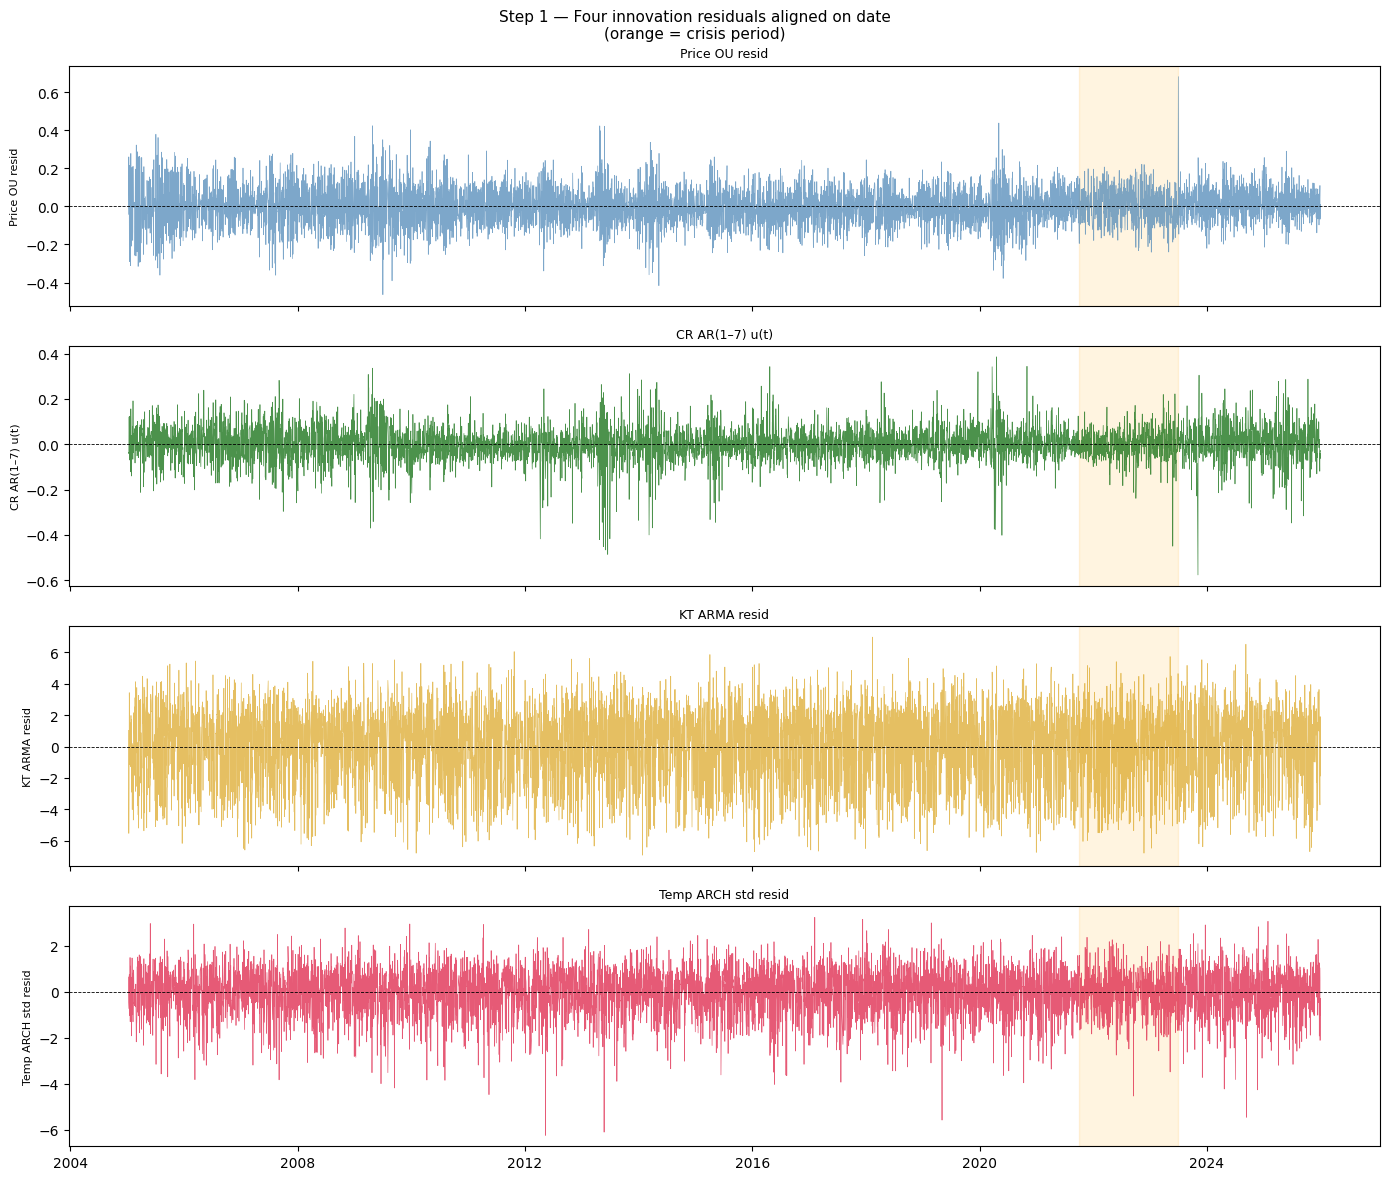

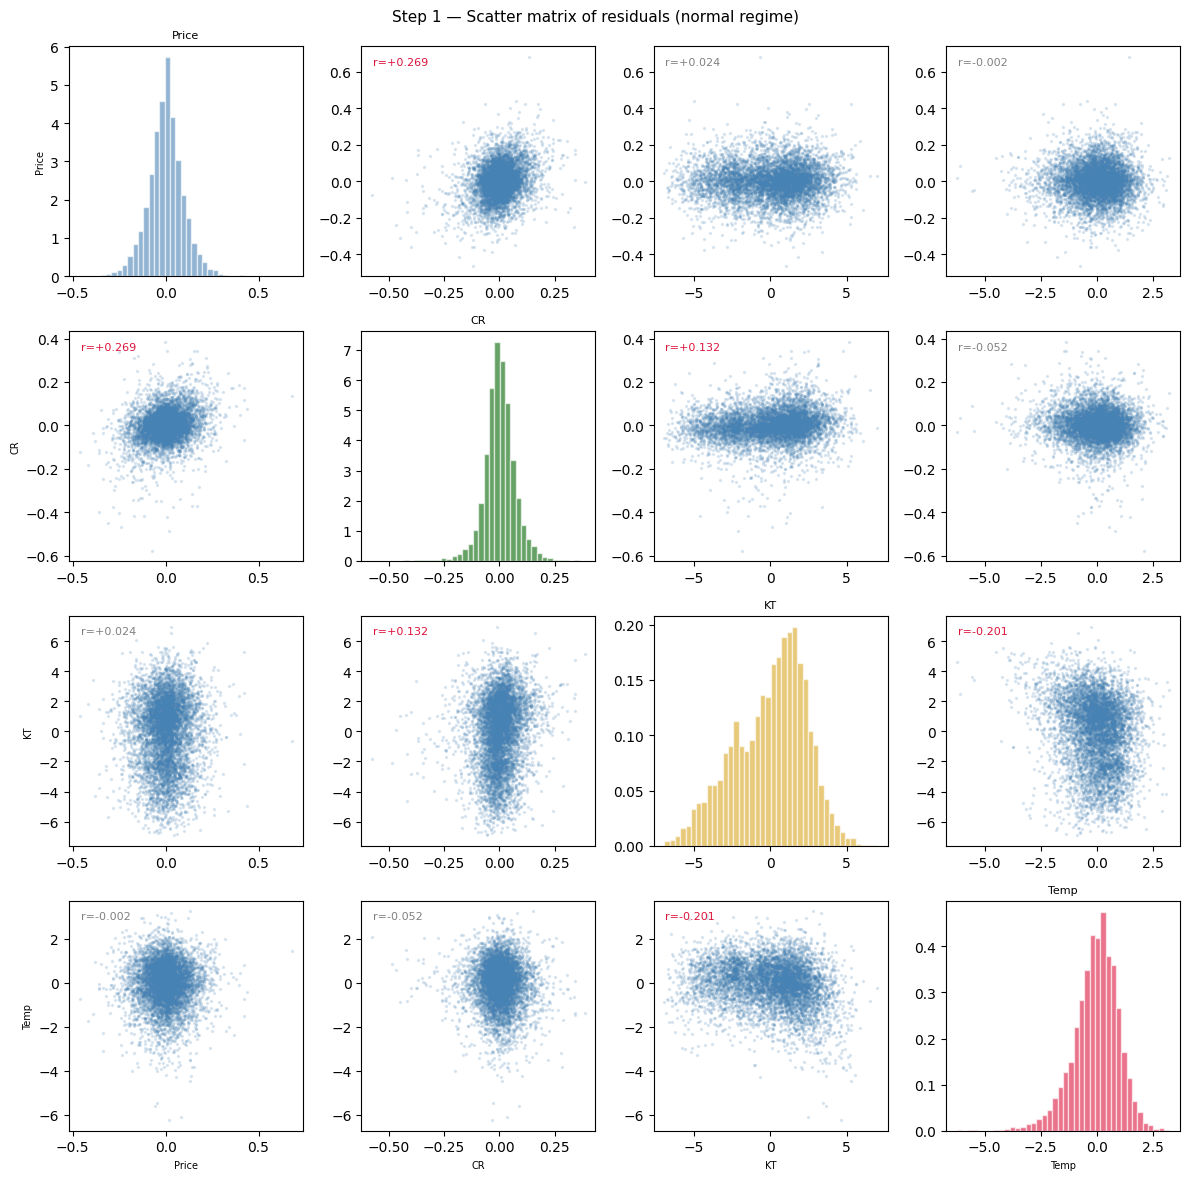

In [88]:
# STEP 1D — Quick summary statistics and plot
# ─────────────────────────────────────────────────────────────────────────────
 
resid_cols = ["eps_price", "eps_cr", "eps_kt", "eps_temp"]
labels_map = {
    "eps_price": "Price OU resid",
    "eps_cr":    "CR AR(1–7) u(t)",
    "eps_kt":    "KT ARMA resid",
    "eps_temp":  "Temp ARCH std resid",
}
 
print(f"\n── Step 1D: Summary statistics (normal regime) ──────────────────")
print(f"  {'Series':<22}  {'mean':>8}  {'std':>8}  "
      f"{'skew':>7}  {'kurt':>7}  {'min':>8}  {'max':>8}")
print(f"  {'-'*22}  {'-'*8}  {'-'*8}  "
      f"{'-'*7}  {'-'*7}  {'-'*8}  {'-'*8}")
for col in resid_cols:
    if col not in df_normal.columns:
        continue
    s = df_normal[col]
    print(f"  {labels_map[col]:<22}  "
          f"{s.mean():>8.5f}  {s.std():>8.5f}  "
          f"{stats.skew(s):>7.3f}  {stats.kurtosis(s):>7.3f}  "
          f"{s.min():>8.4f}  {s.max():>8.4f}")
 
# time series plot of all four residuals
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
colors = ["steelblue", "darkgreen", "goldenrod", "crimson"]
for i, (col, color) in enumerate(zip(resid_cols, colors)):
    if col not in df_resid.columns:
        continue
    ax = axes[i]
    ax.plot(df_resid["date"], df_resid[col],
            lw=0.5, color=color, alpha=0.7)
    ax.axhline(0, color="black", lw=0.6, ls="--")
    ax.axvspan(pd.Timestamp(CRISIS_START),
               pd.Timestamp(CRISIS_END),
               alpha=0.12, color="orange")
    ax.set_ylabel(labels_map[col], fontsize=8)
    ax.set_title(labels_map[col], fontsize=9)
 
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("Step 1 — Four innovation residuals aligned on date\n"
             "(orange = crisis period)", fontsize=11)
plt.tight_layout()
plt.show()
 
# scatter matrix of residuals (normal regime)
n_cols = len([c for c in resid_cols if c in df_normal.columns])
fig, axes = plt.subplots(n_cols, n_cols, figsize=(12, 12))
col_list = [c for c in resid_cols if c in df_normal.columns]
 
for i, ci in enumerate(col_list):
    for j, cj in enumerate(col_list):
        ax = axes[i, j]
        if i == j:
            ax.hist(df_normal[ci], bins=40, density=True,
                    color=colors[i], alpha=0.6, edgecolor="white")
            ax.set_title(labels_map[ci].split()[0], fontsize=8)
        else:
            ax.scatter(df_normal[cj], df_normal[ci],
                       s=2, alpha=0.15, color="steelblue")
            r, p = stats.pearsonr(df_normal[ci], df_normal[cj])
            ax.text(0.05, 0.92, f"r={r:+.3f}",
                    transform=ax.transAxes, fontsize=8,
                    color="crimson" if abs(r) > 0.1 else "grey")
        if j == 0:
            ax.set_ylabel(labels_map[ci].split()[0], fontsize=7)
        if i == n_cols - 1:
            ax.set_xlabel(labels_map[cj].split()[0], fontsize=7)
 
plt.suptitle("Step 1 — Scatter matrix of residuals (normal regime)",
             fontsize=11)
plt.tight_layout()
plt.show()
 

In [89]:
# STEP 2 — Marginal distribution diagnostics

resid_cols  = ["eps_price", "eps_cr", "eps_kt", "eps_temp"]
labels_map  = {
    "eps_price": "Price OU resid",
    "eps_cr":    "CR AR(1–7) u(t)",
    "eps_kt":    "KT ARMA resid",
    "eps_temp":  "Temp ARCH std resid",
}
colors_map  = {
    "eps_price": "steelblue",
    "eps_cr":    "darkgreen",
    "eps_kt":    "goldenrod",
    "eps_temp":  "crimson",
}
 
print("── Step 2: Marginal distribution diagnostics ────────────────────")
print(f"  Sample: normal regime  n={len(df_normal)}")
 

── Step 2: Marginal distribution diagnostics ────────────────────
  Sample: normal regime  n=6306


In [90]:
# 2A — Summary statistics
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 2A: Summary statistics ──────────────────────────────────")
print(f"  {'Series':<22}  {'mean':>9}  {'std':>8}  "
      f"{'skew':>7}  {'kurt':>7}  {'p5':>8}  {'p95':>8}")
print(f"  {'-'*22}  {'-'*9}  {'-'*8}  "
      f"{'-'*7}  {'-'*7}  {'-'*8}  {'-'*8}")
 
for col in resid_cols:
    if col not in df_normal.columns:
        continue
    s = df_normal[col].dropna()
    print(f"  {labels_map[col]:<22}  "
          f"{s.mean():>9.5f}  {s.std():>8.5f}  "
          f"{stats.skew(s):>7.3f}  {stats.kurtosis(s):>7.3f}  "
          f"{np.percentile(s, 5):>8.4f}  {np.percentile(s, 95):>8.4f}")


── Step 2A: Summary statistics ──────────────────────────────────
  Series                       mean       std     skew     kurt        p5       p95
  ----------------------  ---------  --------  -------  -------  --------  --------
  Price OU resid            0.00008   0.09450    0.063    1.610   -0.1558    0.1545
  CR AR(1–7) u(t)           0.00050   0.07305   -0.395    4.540   -0.1097    0.1168
  KT ARMA resid            -0.00099   2.33721   -0.415   -0.359   -4.3006    3.3255
  Temp ARCH std resid      -0.04819   1.00312   -0.650    1.480   -1.8202    1.4155


In [91]:
# 2B — Formal diagnostics: ADF, Ljung-Box, ARCH-LM, Jarque-Bera
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 2B: Formal diagnostics (normal regime) ──────────────────")
 
for col in resid_cols:
    if col not in df_normal.columns:
        continue
    s = df_normal[col].dropna().values
    label = labels_map[col]
 
    print(f"\n  [{label}]")
 
    # ADF stationarity
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(s, autolag="AIC")
    print(f"    ADF     : stat={adf_stat:.3f}  p={adf_p:.4f}  "
          f"{'✓ stationary' if adf_p < 0.05 else '✗ non-stationary'}")
 
    # mean check (t-test H0: mean=0)
    t_stat, t_p = stats.ttest_1samp(s, 0)
    print(f"    Mean=0  : stat={t_stat:.3f}  p={t_p:.4f}  "
          f"{'✓ mean≈0' if t_p > 0.05 else '✗ mean≠0'}")
 
    # Ljung-Box
    lb = acorr_ljungbox(s, lags=[1, 5, 7, 14], return_df=True)
    lb_str = "  ".join([
        f"lag{lag}:{'✓' if row['lb_pvalue']>0.05 else '✗'}"
        for lag, row in lb.iterrows()
    ])
    print(f"    LB      : {lb_str}")
 
    # ARCH-LM
    arch_stat, arch_p, _, _ = het_arch(s, nlags=5)
    print(f"    ARCH    : p={arch_p:.4f}  "
          f"{'✓ no ARCH' if arch_p > 0.05 else '✗ ARCH present'}")
 
    # Jarque-Bera
    jb_stat, jb_p = stats.jarque_bera(s)
    print(f"    JB      : p={jb_p:.4f}  "
          f"{'normal' if jb_p > 0.05 else 'non-normal'}")


── Step 2B: Formal diagnostics (normal regime) ──────────────────

  [Price OU resid]
    ADF     : stat=-7.899  p=0.0000  ✓ stationary
    Mean=0  : stat=0.068  p=0.9462  ✓ mean≈0
    LB      : lag1:✗  lag5:✗  lag7:✗  lag14:✗
    ARCH    : p=0.0000  ✗ ARCH present
    JB      : p=0.0000  non-normal

  [CR AR(1–7) u(t)]
    ADF     : stat=-16.923  p=0.0000  ✓ stationary
    Mean=0  : stat=0.544  p=0.5868  ✓ mean≈0
    LB      : lag1:✗  lag5:✗  lag7:✗  lag14:✗
    ARCH    : p=0.0000  ✗ ARCH present
    JB      : p=0.0000  non-normal

  [KT ARMA resid]
    ADF     : stat=-78.816  p=0.0000  ✓ stationary
    Mean=0  : stat=-0.034  p=0.9731  ✓ mean≈0
    LB      : lag1:✓  lag5:✓  lag7:✓  lag14:✓
    ARCH    : p=0.4373  ✓ no ARCH
    JB      : p=0.0000  non-normal

  [Temp ARCH std resid]
    ADF     : stat=-34.925  p=0.0000  ✓ stationary
    Mean=0  : stat=-3.815  p=0.0001  ✗ mean≠0
    LB      : lag1:✓  lag5:✗  lag7:✗  lag14:✗
    ARCH    : p=0.2309  ✓ no ARCH
    JB      : p=0.0000  non-

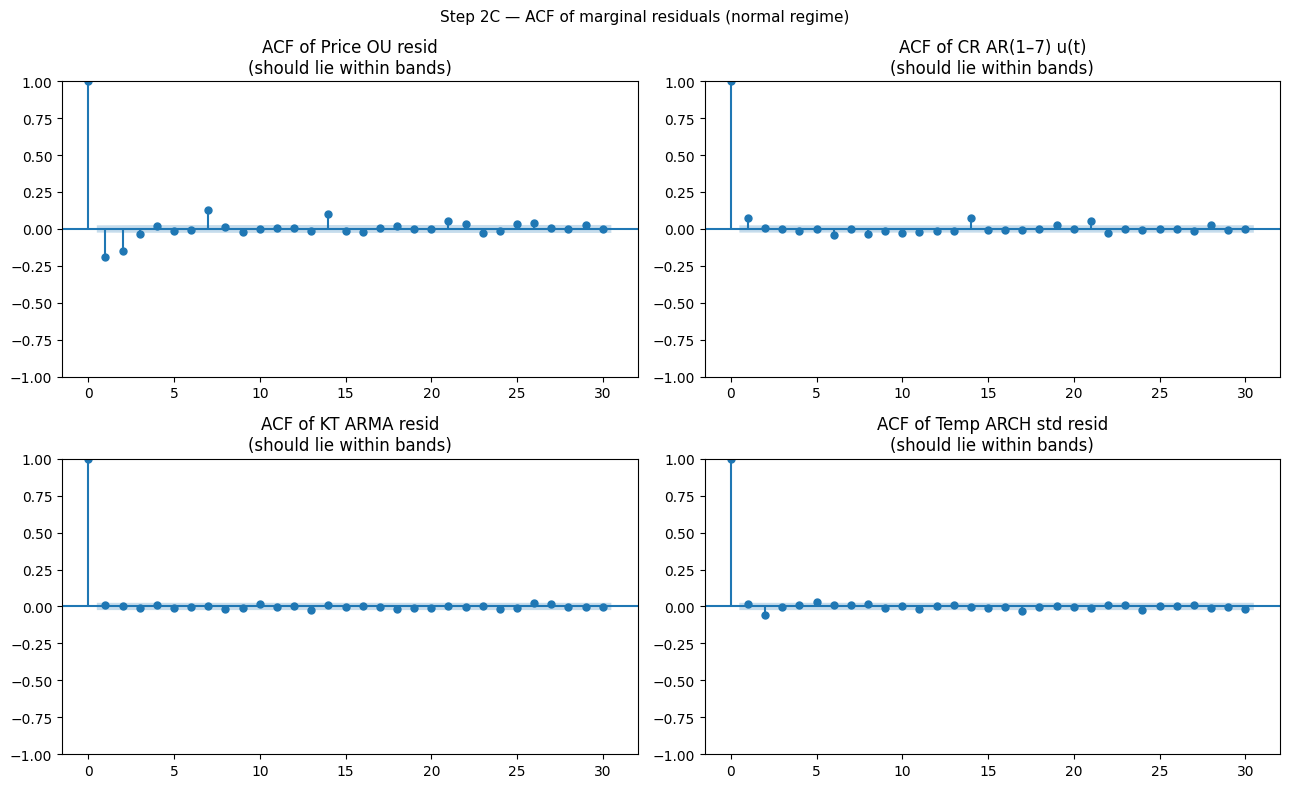

In [92]:
# 2C — ACF plots for all four series
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes_flat = axes.flatten()
 
for i, col in enumerate(resid_cols):
    if col not in df_normal.columns:
        continue
    s = df_normal[col].dropna().values
    plot_acf(s, lags=30, ax=axes_flat[i])
    axes_flat[i].set_title(f"ACF of {labels_map[col]}\n"
                            f"(should lie within bands)")
 
plt.suptitle("Step 2C — ACF of marginal residuals (normal regime)",
             fontsize=11)
plt.tight_layout()
plt.show()

# Probability Integral Transform 

In [93]:
# ── capture rate parameters ───────────────────────────────────────────────────
# 1. Prepare data
x_cr = df_normal["eps_cr"].dropna().values
sigma_cr = float(x_cr.std(ddof=1))

# 2. Objective Grid Search for nu (2.1 to 30.0)
nu_grid = np.linspace(2.1, 30.0, 100)

def get_cr_ll(nu):
    # Scale adjustment ensures the t-distribution variance matches the data std
    scale = sigma_cr * np.sqrt((nu - 2) / nu)
    return np.sum(t_dist.logpdf(x_cr, df=nu, loc=0, scale=scale))

# 3. Find optimal parameters
ll_values = [get_cr_ll(n) for n in nu_grid]
nu_cr = float(nu_grid[np.argmax(ll_values)])
scale_t_cr = sigma_cr * np.sqrt((nu_cr - 2) / nu_cr)

print(f"── Capture Rate (CR) PIT Estimation ──────────────────────────")
print(f"  Best nu    : {nu_cr:.2f}")
print(f"  Best scale : {scale_t_cr:.5f} (Empirical σ={sigma_cr:.5f})")
 

── Capture Rate (CR) PIT Estimation ──────────────────────────
  Best nu    : 4.07
  Best scale : 0.05211 (Empirical σ=0.07305)


In [94]:
# ── energy price parameters ───────────────────────────────────────────────────
# eps_price are OU innovations — assume Gaussian (standard assumption
# in Borovkova-Schmeck framework). If a ν was estimated, load it here.
try:
    with open(models_path / "Energy price" / "price_ou_params.pkl", "rb") as f:
        price_ou = pickle.load(f)

    # use full-sample OU sigma for the PIT
    ou_regime   = price_ou[price_ou["default_regime"]]
    sigma_price = float(price_ou["sigma_eps_price"])
    nu_price    = int(price_ou.get("nu_price", 0))

    if nu_price > 2:
        scale_t_price = sigma_price * np.sqrt((nu_price-2)/nu_price)
        print(f"  Price : ν={nu_price}  σ={sigma_price:.5f}  "
              f"scale_t={scale_t_price:.5f}  "
              f"[regime={price_ou['default_regime']}]")
    else:
        nu_price = 0
        print(f"  Price : Gaussian  σ={sigma_price:.5f}  "
              f"[regime={price_ou['default_regime']}]")
        print(f"  Price OU: h={ou_regime['h']:.5f}  "
              f"σ_ou={ou_regime['sigma']:.5f}  "
              f"HL={ou_regime['hl_days']:.1f} days")

except FileNotFoundError:
    sigma_price = float(df_normal["eps_price"].std(ddof=1))
    nu_price    = 0
    print(f"  Price : params not found — using empirical σ={sigma_price:.5f}")

  Price : Gaussian  σ=0.09374  [regime=ou_pre_crisis]
  Price OU: h=0.03363  σ_ou=0.09142  HL=20.6 days


In [95]:
# KT ARMA residuals passed ARCH-LM → Gaussian assumption is adequate
sigma_kt = float(df_normal["eps_kt"].std(ddof=1))
nu_kt    = 0   # Gaussian
print(f"  KT    : Gaussian  σ={sigma_kt:.5f}")

  KT    : Gaussian  σ=2.33721


In [96]:
""" # ── temperature parameters ────────────────────────────────────────────────────
# temperature AR-ARCH standardised residuals — already standardised (std≈1)
# use t-distribution if ν was stored, otherwise Gaussian
sigma_temp = float(df_normal["eps_temp"].std(ddof=1))
try:
    with open(models_path / "Temperature" / "temp_arch_model.joblib", "rb") as f:
        import joblib
        temp_model = joblib.load(f)
    nu_temp = 0   # ARCH model handles variance — residuals approx Gaussian
    print(f"  Temp  : Gaussian (ARCH standardised)  σ={sigma_temp:.5f}")
except Exception:
    nu_temp = 0
    print(f"  Temp  : Gaussian  σ={sigma_temp:.5f}") """

' # ── temperature parameters ────────────────────────────────────────────────────\n# temperature AR-ARCH standardised residuals — already standardised (std≈1)\n# use t-distribution if ν was stored, otherwise Gaussian\nsigma_temp = float(df_normal["eps_temp"].std(ddof=1))\ntry:\n    with open(models_path / "Temperature" / "temp_arch_model.joblib", "rb") as f:\n        import joblib\n        temp_model = joblib.load(f)\n    nu_temp = 0   # ARCH model handles variance — residuals approx Gaussian\n    print(f"  Temp  : Gaussian (ARCH standardised)  σ={sigma_temp:.5f}")\nexcept Exception:\n    nu_temp = 0\n    print(f"  Temp  : Gaussian  σ={sigma_temp:.5f}") '

In [97]:
# ── temperature parameters ────────────────────────────────────────────────────
# 1. Prepare data
x_temp = df_normal["eps_temp"].dropna().values
std_temp = x_temp.std(ddof=1)

# 2. Define search grid (2.1 to 30.0)
nu_grid = np.linspace(2.1, 30.0, 100)

def get_log_likelihood(nu):
    # Scale adjustment: std * sqrt((nu-2)/nu) ensures variance matches the data
    scale = std_temp * np.sqrt((nu - 2) / nu)
    return np.sum(t_dist.logpdf(x_temp, df=nu, loc=0, scale=scale))

# 3. Optimize
ll_values = [get_log_likelihood(n) for n in nu_grid]
nu_temp = float(nu_grid[np.argmax(ll_values)])
scale_temp = std_temp * np.sqrt((nu_temp - 2) / nu_temp)

print(f"── Temperature parameters ─────────────────────────────────")
print(f"Best nu    : {nu_temp:.2f}")
print(f"Best scale : {scale_temp:.5f} (Std: {std_temp:.5f})")

── Temperature parameters ─────────────────────────────────
Best nu    : 7.45
Best scale : 0.85807 (Std: 1.00312)


In [98]:
# STEP 3B — Apply PIT to each series
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 3B: Apply PIT ───────────────────────────────────────────")
 
df_uniform = df_normal[["date", "crisis"]].copy()

# ── U_price ───────────────────────────────────────────────────────────────────
if nu_price > 2:
    scale_t_price = sigma_price * np.sqrt((nu_price - 2) / nu_price)
    U_price = t_dist.cdf(
        df_normal["eps_price"].values / scale_t_price, df=nu_price
    )
    pit_label_price = f"t(ν={nu_price})"
else:
    U_price = norm.cdf(df_normal["eps_price"].values, 0, sigma_price)
    pit_label_price = "Gaussian"
 
df_uniform["U_price"] = U_price
print(f"  U_price [{pit_label_price}]: "
      f"mean={U_price.mean():.4f}  std={U_price.std():.4f}")
 
# ── U_cr ──────────────────────────────────────────────────────────────────────
U_cr = t_dist.cdf(
    df_normal["eps_cr"].values / scale_t_cr, df=nu_cr
)
df_uniform["U_cr"] = U_cr
print(f"  U_cr   [t(ν={nu_cr})]     : "
      f"mean={U_cr.mean():.4f}  std={U_cr.std():.4f}")
 
# ── U_kt ──────────────────────────────────────────────────────────────────────
U_kt = norm.cdf(df_normal["eps_kt"].values, 0, sigma_kt)
df_uniform["U_kt"] = U_kt
print(f"  U_kt   [Gaussian]  : "
      f"mean={U_kt.mean():.4f}  std={U_kt.std():.4f}")
 
# ── U_temp ────────────────────────────────────────────────────────────────────
# Apply the Probability Integral Transform (PIT) using the Student-t distribution
# Note: nu_temp and scale_temp are the values estimated via the MLE grid search
U_temp = t_dist.cdf(df_normal["eps_temp"].values, df=nu_temp, loc=0, scale=scale_temp)
df_uniform["U_temp"] = U_temp
print(f"  U_temp [t(ν={nu_temp})]  : "
      f"mean={U_temp.mean():.4f}  std={U_temp.std():.4f}")
 
uniform_cols = ["U_price", "U_cr", "U_kt", "U_temp"]


── Step 3B: Apply PIT ───────────────────────────────────────────
  U_price [Gaussian]: mean=0.5003  std=0.2751
  U_cr   [t(ν=4.072727272727272)]     : mean=0.5026  std=0.2879
  U_kt   [Gaussian]  : mean=0.5137  std=0.2937
  U_temp [t(ν=7.454545454545455)]  : mean=0.5003  std=0.2891


In [99]:
# STEP 3C — Validate uniformity
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 3C: Uniformity validation ──────────────────────────────")
print(f"  A uniform U[0,1] has: mean=0.500  std=0.289  "
      f"skew=0.000  kurt=-1.200")
print(f"\n  {'Series':<10}  {'mean':>7}  {'std':>7}  "
      f"{'skew':>7}  {'kurt':>7}  {'KS p':>8}")
print(f"  {'-'*10}  {'-'*7}  {'-'*7}  "
      f"{'-'*7}  {'-'*7}  {'-'*8}")
 
for col in uniform_cols:
    u = df_uniform[col].dropna().values
    ks_stat, ks_p = stats.kstest(u, "uniform")
    print(f"  {col:<10}  "
          f"{u.mean():>7.4f}  {u.std():>7.4f}  "
          f"{stats.skew(u):>7.4f}  {stats.kurtosis(u):>7.4f}  "
          f"{ks_p:>8.4f}  "
          f"{'✓' if ks_p > 0.05 else '✗'}")


── Step 3C: Uniformity validation ──────────────────────────────
  A uniform U[0,1] has: mean=0.500  std=0.289  skew=0.000  kurt=-1.200

  Series         mean      std     skew     kurt      KS p
  ----------  -------  -------  -------  -------  --------
  U_price      0.5003   0.2751  -0.0091  -0.9889    0.0000  ✗
  U_cr         0.5026   0.2879   0.0242  -1.1809    0.2545  ✓
  U_kt         0.5137   0.2937  -0.2490  -1.2452    0.0000  ✗
  U_temp       0.5003   0.2891  -0.1085  -1.2101    0.0065  ✗


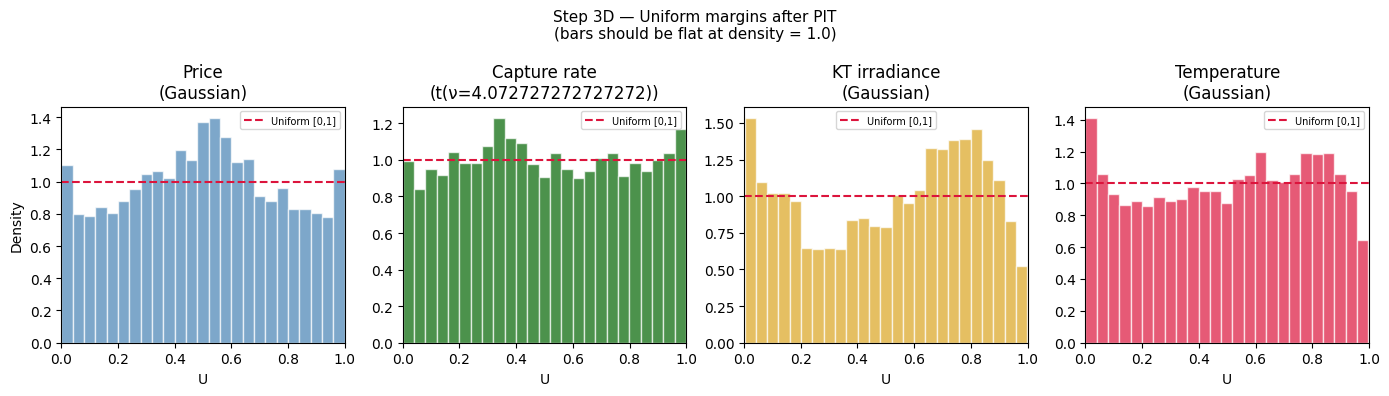

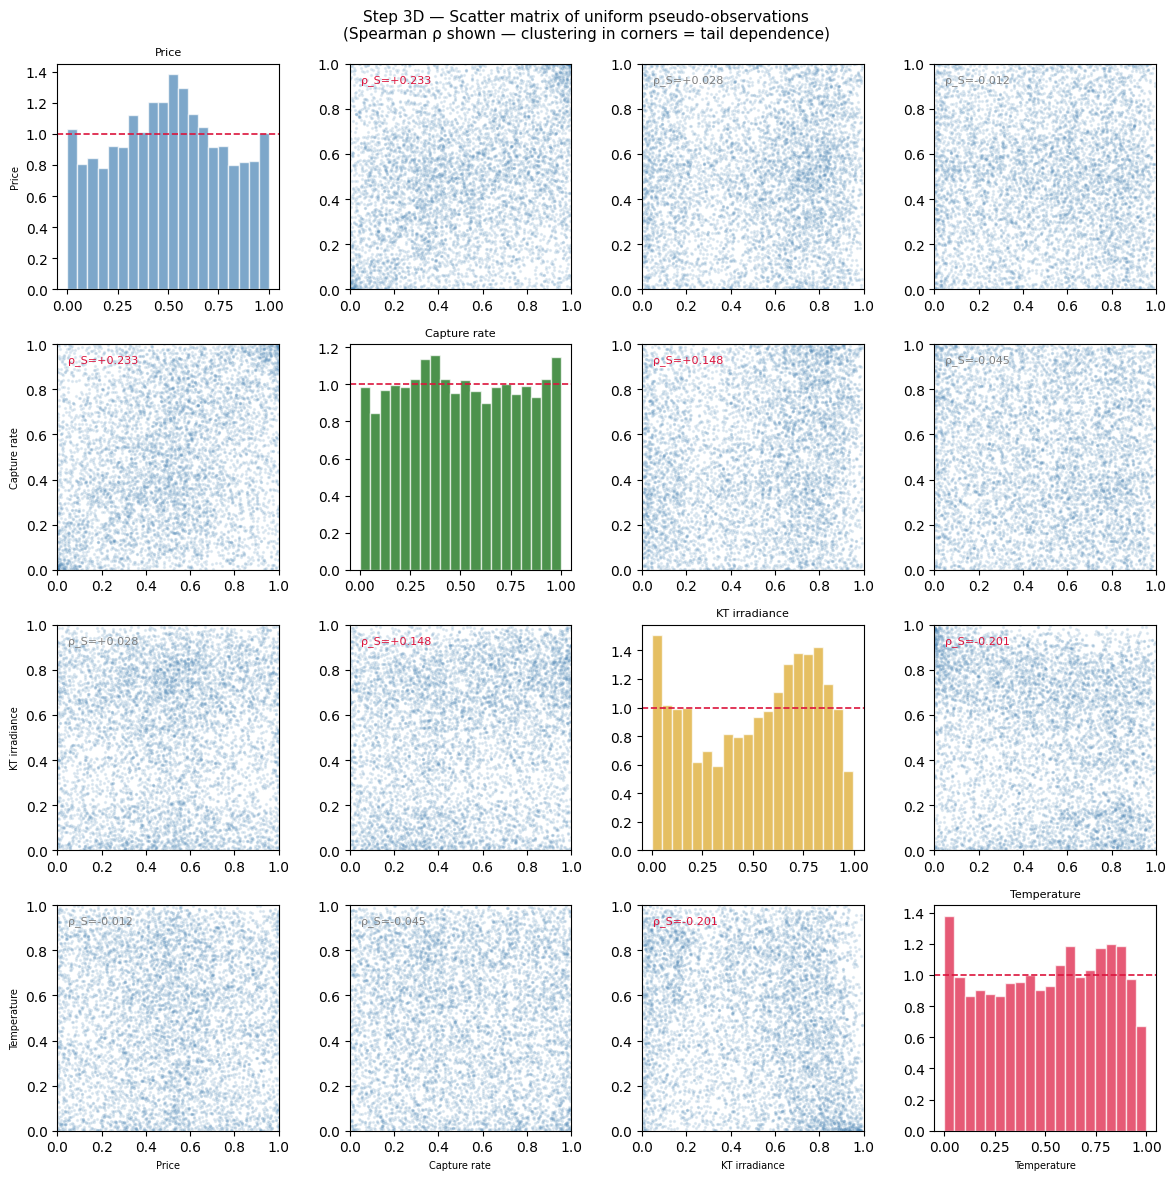

In [ ]:
# STEP 3D — Plots: histograms and scatter matrix of uniform margins
# ─────────────────────────────────────────────────────────────────────────────
 
labels_u = {
    "U_price": "Price",
    "U_cr":    "Capture rate",
    "U_kt":    "KT irradiance",
    "U_temp":  "Temperature",
}
colors_u = {
    "U_price": "steelblue",
    "U_cr":    "darkgreen",
    "U_kt":    "goldenrod",
    "U_temp":  "crimson",
}

# ── histogram of each uniform margin ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, col in enumerate(uniform_cols):
    u   = df_uniform[col].dropna().values
    ax  = axes[i]
    ax.hist(u, bins=25, density=True, color=colors_u[col],
            alpha=0.7, edgecolor="white")
    ax.axhline(1.0, color="crimson", lw=1.5, ls="--",
               label="Uniform [0,1]")
    ax.set_title(f"{labels_u[col]}\n({pit_label_price if col=='U_price' else 'Gaussian' if col in ['U_kt','U_temp'] else f't(ν={nu_cr})'})")
    ax.set_xlabel("U")
    ax.set_ylabel("Density" if i == 0 else "")
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1)
 
plt.suptitle("Step 3D — Uniform margins after PIT\n"
             "(bars should be flat at density = 1.0)", fontsize=11)
plt.tight_layout()
plt.show()
 
# ── scatter matrix of uniform margins ────────────────────────────────────────
n_u    = len(uniform_cols)
fig, axes = plt.subplots(n_u, n_u, figsize=(12, 12))
 
for i, ci in enumerate(uniform_cols):
    for j, cj in enumerate(uniform_cols):
        ax = axes[i, j]
        if i == j:
            u = df_uniform[ci].dropna().values
            ax.hist(u, bins=20, density=True,
                    color=colors_u[ci], alpha=0.7, edgecolor="white")
            ax.axhline(1.0, color="crimson", lw=1.2, ls="--")
            ax.set_title(labels_u[ci], fontsize=8)
        else:
            ui = df_uniform[ci].dropna()
            uj = df_uniform[cj].dropna()
            # align on common index
            common = ui.index.intersection(uj.index)
            ax.scatter(uj.loc[common], ui.loc[common],
                       s=2, alpha=0.12, color="steelblue")
            r, p = stats.spearmanr(uj.loc[common], ui.loc[common])
            ax.text(0.05, 0.92, f"ρ_S={r:+.3f}",
                    transform=ax.transAxes, fontsize=8,
                    color="crimson" if abs(r) > 0.1 else "grey")
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        if j == 0:
            ax.set_ylabel(labels_u[ci], fontsize=7)
        if i == n_u - 1:
            ax.set_xlabel(labels_u[cj], fontsize=7)
 
plt.suptitle("Step 3D — Scatter matrix of uniform pseudo-observations\n"
             "(Spearman ρ shown — clustering in corners = tail dependence)",
             fontsize=11)
plt.tight_layout()
plt.show()
 

#  Empirical correlation analysis

In [101]:
resid_cols   = ["eps_price", "eps_cr", "eps_kt", "eps_temp"]
uniform_cols = ["U_price",   "U_cr",   "U_kt",   "U_temp"]
short_labels = ["Price",     "CR",     "KT",     "Temp"]
colors_u     = ["steelblue", "darkgreen", "goldenrod", "crimson"]
 

In [102]:
# STEP 4A — Pearson and Spearman correlation matrices
# ─────────────────────────────────────────────────────────────────────────────
 
print("── Step 4A: Correlation matrices (normal regime) ────────────────")
 
data_resid   = df_normal[resid_cols].dropna()
data_uniform = df_uniform[uniform_cols].dropna()
n_obs        = len(data_resid)
 
corr_pearson  = data_resid.corr(method="pearson")
corr_spearman = data_resid.corr(method="spearman")
 
# Kendall's tau — most robust for copula fitting
corr_kendall = pd.DataFrame(
    np.zeros((4, 4)), index=resid_cols, columns=resid_cols
)
for i, ci in enumerate(resid_cols):
    for j, cj in enumerate(resid_cols):
        if i == j:
            corr_kendall.loc[ci, cj] = 1.0
        elif i < j:
            tau, _ = kendalltau(
                data_resid[ci].values,
                data_resid[cj].values
            )
            corr_kendall.loc[ci, cj] = tau
            corr_kendall.loc[cj, ci] = tau
 
# convert Kendall τ to linear correlation for Gaussian copula
# ρ = sin(π/2 · τ)   [van der Waerden / Lindskog formula]
corr_from_kendall = np.sin(np.pi / 2 * corr_kendall.values)
corr_from_kendall_df = pd.DataFrame(
    corr_from_kendall,
    index=resid_cols, columns=resid_cols
)
 
print(f"  n = {n_obs} (normal regime)")
 
for name, mat in [
    ("Pearson",                   corr_pearson),
    ("Spearman rank",             corr_spearman),
    ("Kendall τ",                 corr_kendall),
    ("ρ from Kendall (sin(π/2·τ))", corr_from_kendall_df),
]:
    print(f"\n  {name}:")
    header = f"  {'':>12}" + "".join(
        [f"  {l:>8}" for l in short_labels]
    )
    print(header)
    for ci, label in zip(resid_cols, short_labels):
        row_str = f"  {label:>12}"
        for cj in resid_cols:
            row_str += f"  {mat.loc[ci,cj]:>8.4f}"
        print(row_str)
 
# significance tests for Pearson r
print(f"\n  Pearson significance (H0: ρ=0):")
pairs = [
    ("eps_price", "eps_cr",   "price–CR"),
    ("eps_price", "eps_kt",   "price–KT"),
    ("eps_price", "eps_temp", "price–temp"),
    ("eps_cr",    "eps_kt",   "CR–KT"),
    ("eps_cr",    "eps_temp", "CR–temp"),
    ("eps_kt",    "eps_temp", "KT–temp"),
]
print(f"  {'Pair':<16}  {'Pearson r':>10}  {'Spearman ρ':>11}  "
      f"{'Kendall τ':>10}  {'p-value':>9}  sig")
print(f"  {'-'*16}  {'-'*10}  {'-'*11}  "
      f"{'-'*10}  {'-'*9}  ---")
for ci, cj, label in pairs:
    r_p = corr_pearson.loc[ci, cj]
    r_s = corr_spearman.loc[ci, cj]
    r_k = corr_kendall.loc[ci, cj]
    t_s  = r_p * np.sqrt(n_obs - 2) / np.sqrt(1 - r_p**2)
    p_v  = 2 * (1 - stats.t.cdf(abs(t_s), df=n_obs - 2))
    sig  = "***" if p_v<0.001 else "**" if p_v<0.01 else "*" if p_v<0.05 else "n.s."
    print(f"  {label:<16}  {r_p:>10.4f}  {r_s:>11.4f}  "
          f"{r_k:>10.4f}  {p_v:>9.4f}  {sig}")
 

── Step 4A: Correlation matrices (normal regime) ────────────────
  n = 6306 (normal regime)

  Pearson:
                   Price        CR        KT      Temp
         Price    1.0000    0.2686    0.0236   -0.0024
            CR    0.2686    1.0000    0.1324   -0.0519
            KT    0.0236    0.1324    1.0000   -0.2011
          Temp   -0.0024   -0.0519   -0.2011    1.0000

  Spearman rank:
                   Price        CR        KT      Temp
         Price    1.0000    0.2331    0.0283   -0.0123
            CR    0.2331    1.0000    0.1477   -0.0446
            KT    0.0283    0.1477    1.0000   -0.2007
          Temp   -0.0123   -0.0446   -0.2007    1.0000

  Kendall τ:
                   Price        CR        KT      Temp
         Price    1.0000    0.1602    0.0191   -0.0083
            CR    0.1602    1.0000    0.0988   -0.0297
            KT    0.0191    0.0988    1.0000   -0.1356
          Temp   -0.0083   -0.0297   -0.1356    1.0000

  ρ from Kendall (sin(π/2·τ)):
      

In [103]:
# STEP 4B — Tail dependence estimation
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 4B: Tail dependence ──────────────────────────────────────")
print(f"  Empirical tail dependence coefficients")
print(f"  λ_L = P(U_i < q | U_j < q) as q → 0  (lower tail)")
print(f"  λ_U = P(U_i > 1-q | U_j > 1-q) as q → 1  (upper tail)")
 
q_levels = [0.05, 0.10, 0.15]
key_pairs = [
    ("U_price", "U_cr",   "price–CR"),
    ("U_price", "U_kt",   "price–KT"),
    ("U_cr",    "U_kt",   "CR–KT"),
    ("U_kt",    "U_temp", "KT–temp"),
]
 
print(f"\n  {'Pair':<14}  {'q':>5}  {'λ_L':>7}  {'λ_U':>7}")
print(f"  {'-'*14}  {'-'*5}  {'-'*7}  {'-'*7}")
 
tail_dep = {}
for ci, cj, label in key_pairs:
    tail_dep[label] = {}
    ui = data_uniform[ci].values
    uj = data_uniform[cj].values
    for q in q_levels:
        n_lower = np.sum((ui < q) & (uj < q))
        n_upper = np.sum((ui > 1-q) & (uj > 1-q))
        n_q     = np.sum(uj < q)
        n_q_u   = np.sum(uj > 1-q)
        lam_L   = n_lower / max(n_q, 1)
        lam_U   = n_upper / max(n_q_u, 1)
        tail_dep[label][q] = {"lambda_L": lam_L, "lambda_U": lam_U}
        print(f"  {label:<14}  {q:>5.2f}  {lam_L:>7.4f}  {lam_U:>7.4f}")


── Step 4B: Tail dependence ──────────────────────────────────────
  Empirical tail dependence coefficients
  λ_L = P(U_i < q | U_j < q) as q → 0  (lower tail)
  λ_U = P(U_i > 1-q | U_j > 1-q) as q → 1  (upper tail)

  Pair                q      λ_L      λ_U
  --------------  -----  -------  -------
  price–CR         0.05   0.2412   0.1811
  price–CR         0.10   0.2634   0.2522
  price–CR         0.15   0.2789   0.2764
  price–KT         0.05   0.0473   0.0585
  price–KT         0.10   0.0856   0.1239
  price–KT         0.15   0.1283   0.1534
  CR–KT            0.05   0.0452   0.1228
  CR–KT            0.10   0.1034   0.1513
  CR–KT            0.15   0.1622   0.2105
  KT–temp          0.05   0.0600   0.0105
  KT–temp          0.10   0.0901   0.0458
  KT–temp          0.15   0.1142   0.0775


In [104]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4C — Rolling correlation analysis
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n── Step 4C: Rolling correlation (365-day window) ────────────────")

df_roll = df_resid[["date"] + resid_cols].copy()
df_roll["date"] = pd.to_datetime(df_roll["date"])
df_roll = df_roll.set_index("date").sort_index()

roll_window = 365
roll_corrs  = {}

for ci, cj, label in pairs:
    # compute rolling correlation directly on the two series
    roll_r = (
        df_roll[ci]
        .rolling(roll_window, min_periods=180)
        .corr(df_roll[cj])
        .reset_index()
        .rename(columns={ci: "r", "date": "date"})
    )
    roll_r.columns = ["date", "r"]
    roll_corrs[label] = roll_r

# trend test on price–CR rolling correlation
print(f"\n  Trend in ρ(price, CR) over time:")
rc_pc = roll_corrs["price–CR"].dropna(subset=["r"])
if len(rc_pc) > 10:
    r_trend, p_trend = stats.pearsonr(
        rc_pc["r"].values,
        np.arange(len(rc_pc))
    )
    print(f"  r(ρ, time) = {r_trend:+.4f}  p={p_trend:.4f}  "
          f"{'** trending' if p_trend < 0.05 else 'stable'}")


── Step 4C: Rolling correlation (365-day window) ────────────────

  Trend in ρ(price, CR) over time:
  r(ρ, time) = +0.2602  p=0.0000  ** trending


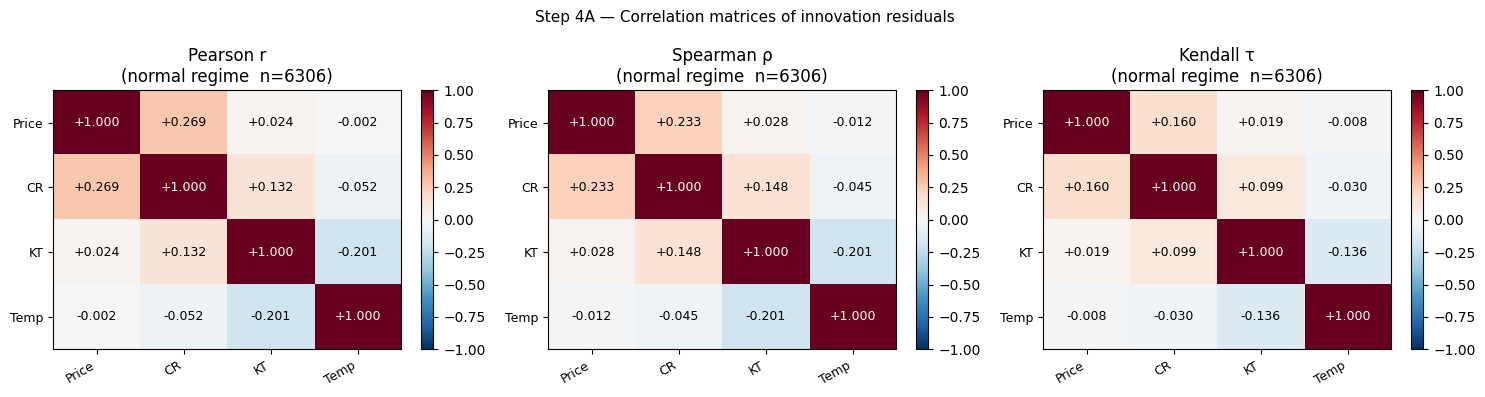

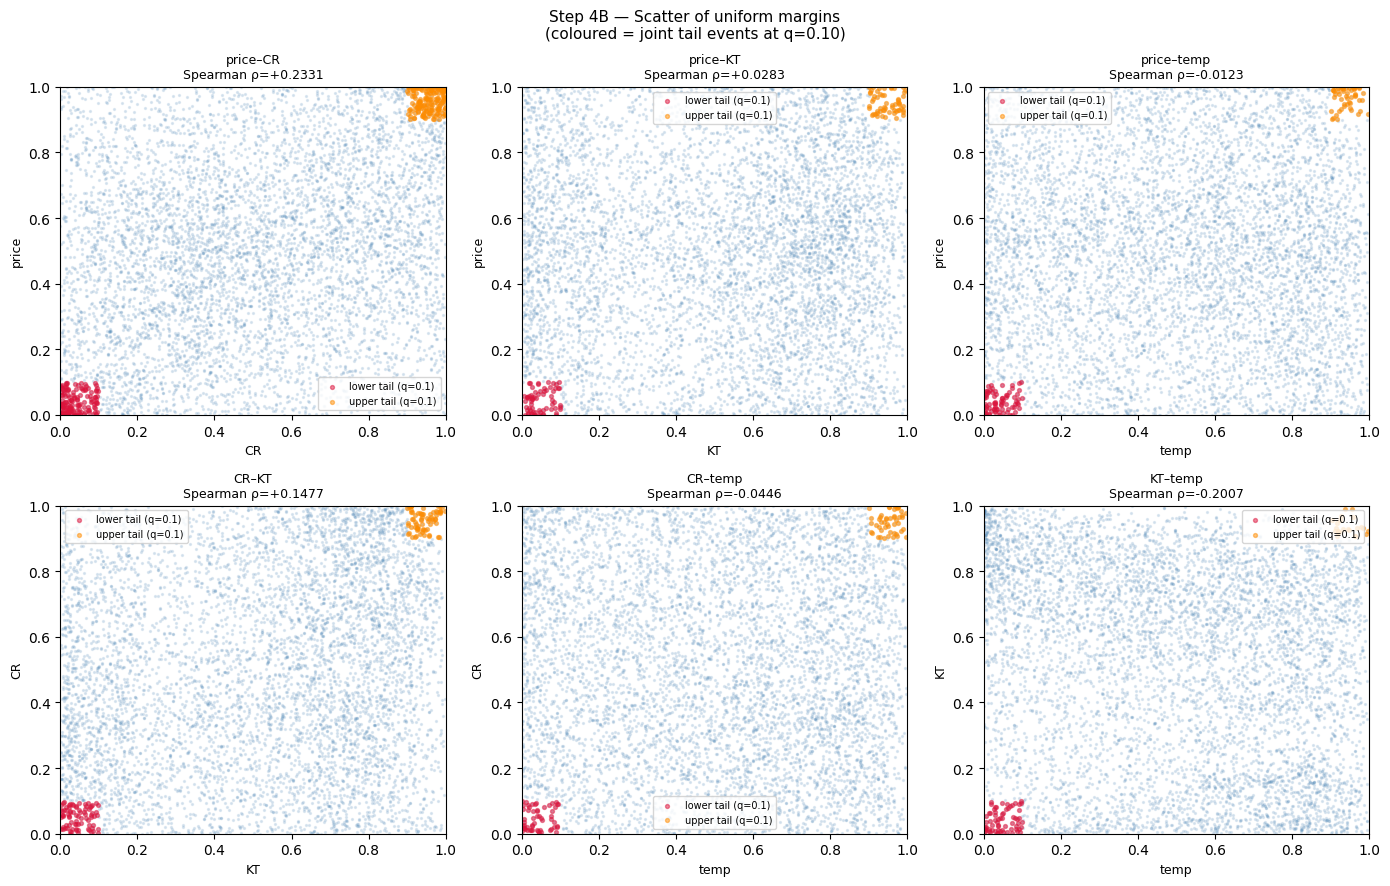

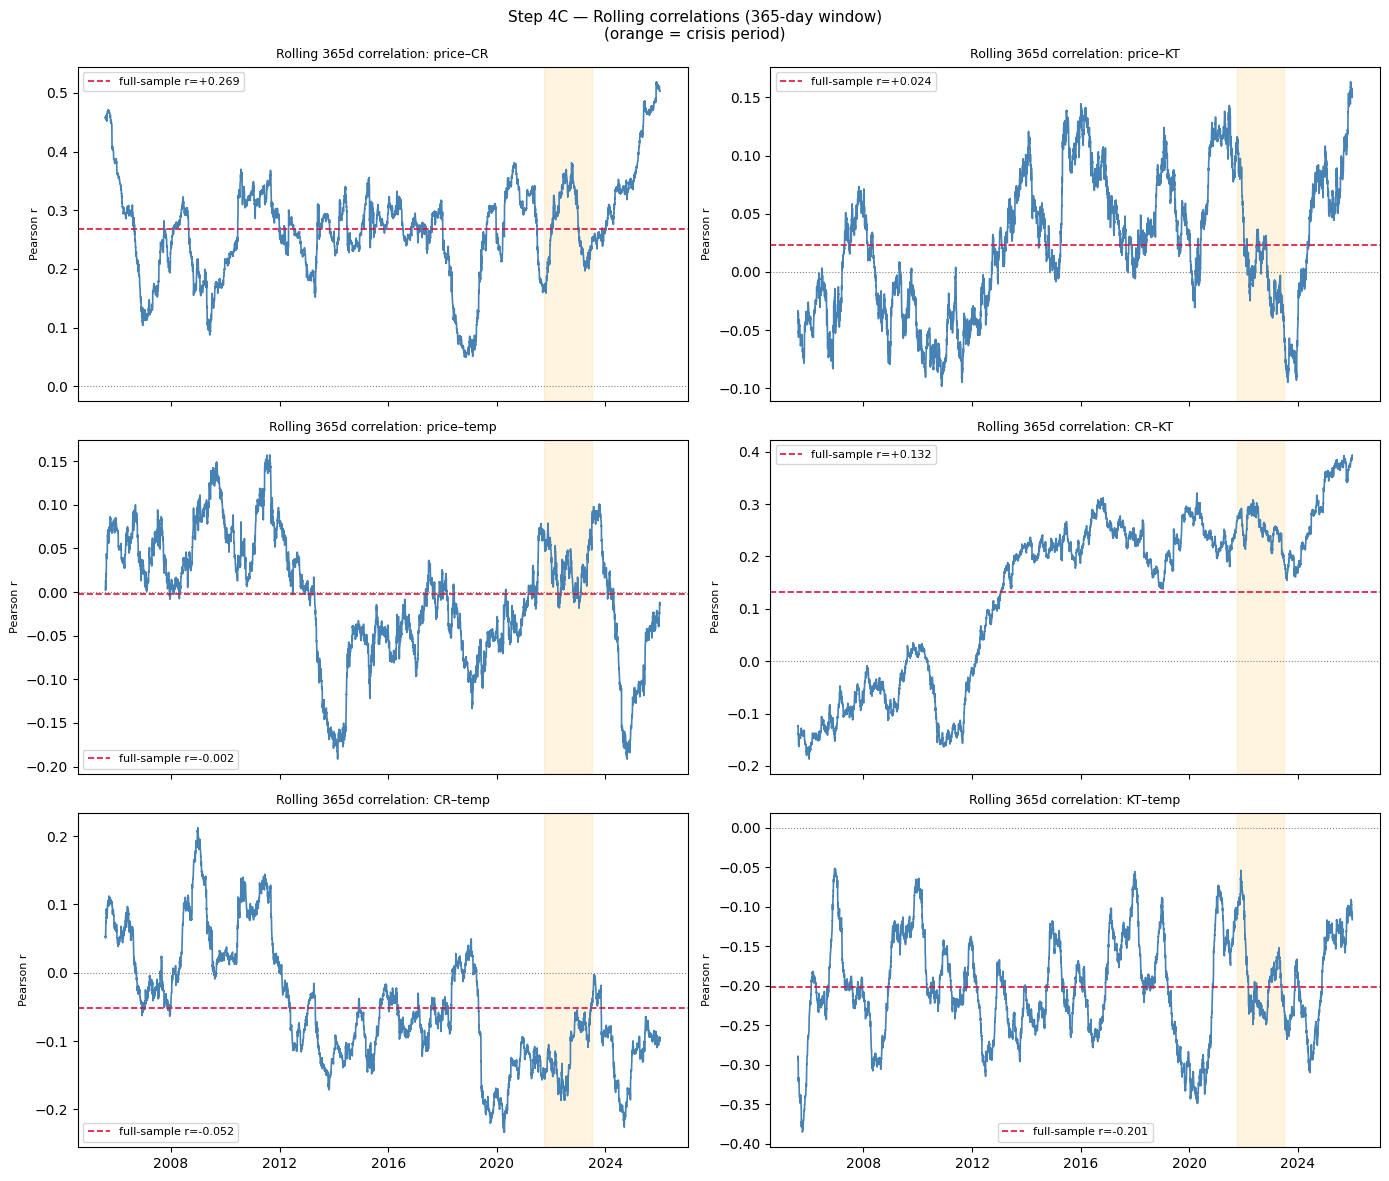


── Step 4 complete ──────────────────────────────────────────────
  Key findings:
    price–CR            r=+0.2686  ρ_S=+0.2331  ***
    price–KT            r=+0.0236  ρ_S=+0.0283  n.s.
    price–temp          r=-0.0024  ρ_S=-0.0123  n.s.
    CR–KT               r=+0.1324  ρ_S=+0.1477  ***
    CR–temp             r=-0.0519  ρ_S=-0.0446  ***
    KT–temp             r=-0.2011  ρ_S=-0.2007  ***


In [105]:
# STEP 4D — Plots
# ─────────────────────────────────────────────────────────────────────────────
 
# ── heatmaps: Pearson, Spearman, Kendall ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
for ax, (mat, title) in zip(axes, [
    (corr_pearson,        "Pearson r"),
    (corr_spearman,       "Spearman ρ"),
    (corr_kendall,        "Kendall τ"),
]):
    n = len(resid_cols)
    im = ax.imshow(mat.values, vmin=-1, vmax=1,
                   cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(short_labels, rotation=30,
                        ha="right", fontsize=9)
    ax.set_yticklabels(short_labels, fontsize=9)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{mat.values[i,j]:+.3f}",
                    ha="center", va="center", fontsize=9,
                    color="white" if abs(mat.values[i,j]) > 0.4
                    else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f"{title}\n(normal regime  n={n_obs})")
 
plt.suptitle("Step 4A — Correlation matrices of innovation residuals",
             fontsize=11)
plt.tight_layout()
plt.show()
 
# ── scatter of key pairs with marginal histograms ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes_flat = axes.flatten()
 
for k, (ci, cj, label) in enumerate(pairs):
    ax = axes_flat[k]
    ui = data_uniform[ci.replace("eps_", "U_")].values
    uj = data_uniform[cj.replace("eps_", "U_")].values
    ax.scatter(uj, ui, s=2, alpha=0.15, color="steelblue")
 
    # mark lower-left corner (joint tail)
    q = 0.10
    mask_ll = (ui < q) & (uj < q)
    mask_ur = (ui > 1-q) & (uj > 1-q)
    ax.scatter(uj[mask_ll], ui[mask_ll], s=8, alpha=0.5,
               color="crimson",   label=f"lower tail (q={q})")
    ax.scatter(uj[mask_ur], ui[mask_ur], s=8, alpha=0.5,
               color="darkorange", label=f"upper tail (q={q})")
 
    r_s = corr_spearman.loc[ci, cj]
    ax.set_xlabel(label.split("–")[1], fontsize=9)
    ax.set_ylabel(label.split("–")[0], fontsize=9)
    ax.set_title(f"{label}\nSpearman ρ={r_s:+.4f}", fontsize=9)
    ax.legend(fontsize=7)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
 
plt.suptitle("Step 4B — Scatter of uniform margins\n"
             "(coloured = joint tail events at q=0.10)",
             fontsize=11)
plt.tight_layout()
plt.show()
 
# ── rolling correlations ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes_flat = axes.flatten()
 
for k, (ci, cj, label) in enumerate(pairs):
    ax = axes_flat[k]
    rc = roll_corrs[label].dropna(subset=["r"])
    ax.plot(rc["date"], rc["r"], lw=1.2, color="steelblue")
    ax.axhline(corr_pearson.loc[ci, cj], color="crimson",
               lw=1.2, ls="--",
               label=f"full-sample r={corr_pearson.loc[ci,cj]:+.3f}")
    ax.axhline(0, color="grey", lw=0.8, ls=":")
    ax.axvspan(pd.Timestamp(CRISIS_START),
               pd.Timestamp(CRISIS_END),
               alpha=0.12, color="orange")
    ax.set_ylabel("Pearson r", fontsize=8)
    ax.set_title(f"Rolling 365d correlation: {label}", fontsize=9)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
plt.suptitle("Step 4C — Rolling correlations (365-day window)\n"
             "(orange = crisis period)", fontsize=11)
plt.tight_layout()
plt.show()
 
print(f"\n── Step 4 complete ──────────────────────────────────────────────")
print(f"  Key findings:")
for ci, cj, label in pairs:
    r_p = corr_pearson.loc[ci, cj]
    r_s = corr_spearman.loc[ci, cj]
    sig_str = "***" if abs(r_p)*np.sqrt(n_obs-2)/np.sqrt(1-r_p**2) > 3.3 \
              else "n.s."
    print(f"    {label:<18}  r={r_p:+.4f}  ρ_S={r_s:+.4f}  {sig_str}")

In [106]:
# check if rolling correlation of u_ar with eps_kt and eps_temp
# still shows a trend after the logistic correction
df_roll_resid = df_normal[["date", "eps_cr", "eps_kt", "eps_temp"]].copy()
df_roll_resid = df_roll_resid.set_index("date").sort_index()

for cj, label in [("eps_kt", "CR–KT"), ("eps_temp", "CR–temp")]:
    roll_r = (
        df_roll_resid["eps_cr"]
        .rolling(365, min_periods=180)
        .corr(df_roll_resid[cj])
    )
    r_trend, p_trend = stats.pearsonr(
        roll_r.dropna().values,
        np.arange(len(roll_r.dropna()))
    )
    print(f"{label}: trend r={r_trend:+.4f}  p={p_trend:.4f}  "
          f"{'** still trending' if p_trend < 0.05 else '✓ stationary after correction'}")

CR–KT: trend r=+0.9020  p=0.0000  ** still trending
CR–temp: trend r=-0.7098  p=0.0000  ** still trending


# Copula selection

In [107]:
copula_path  = Path("../../Code/Models/Copula")
copula_path.mkdir(parents=True, exist_ok=True)
uniform_cols = ["U_cr", "U_kt", "U_temp"]
short_labels = ["CR",   "KT",   "Temp"]
 
# ── clean uniform data ────────────────────────────────────────────────────────
U_mat = df_uniform[uniform_cols].dropna().values
n_obs, n_dim = U_mat.shape
eps_clip = 1e-6
U_mat    = np.clip(U_mat, eps_clip, 1 - eps_clip)
 
# convert to standard normal scores
Z_mat = norm.ppf(U_mat)
 
print(f"── Step 5: Copula selection ──────────────────────────────────────")
print(f"  n={n_obs}  dim={n_dim}")

── Step 5: Copula selection ──────────────────────────────────────
  n=6306  dim=3


In [108]:
# STEP 5A — Gaussian copula
# ─────────────────────────────────────────────────────────────────────────────
 
corr_gauss = np.corrcoef(Z_mat.T)
 
def gaussian_copula_ll(Z, corr):
    n = Z.shape[0]
    try:
        sign, logdet = np.linalg.slogdet(corr)
        if sign <= 0:
            return -np.inf
        corr_inv = np.linalg.inv(corr)
        ll  = -0.5 * n * logdet
        ll -= 0.5 * np.sum(Z @ (corr_inv - np.eye(len(corr))) * Z)
        return float(ll)
    except Exception:
        return -np.inf
 
ll_gauss  = gaussian_copula_ll(Z_mat, corr_gauss)
k_gauss   = n_dim * (n_dim - 1) // 2
aic_gauss = -2 * ll_gauss + 2 * k_gauss
bic_gauss = -2 * ll_gauss + np.log(n_obs) * k_gauss
 
print(f"\n── Step 5A: Gaussian copula ──────────────────────────────────────")
print(f"  LL  = {ll_gauss:.2f}")
print(f"  AIC = {aic_gauss:.2f}")
print(f"  BIC = {bic_gauss:.2f}")
print(f"  k   = {k_gauss}")


── Step 5A: Gaussian copula ──────────────────────────────────────
  LL  = 188.65
  AIC = -371.30
  BIC = -351.05
  k   = 3


In [109]:
# STEP 5B — Student-t copula: grid search over ν
# ─────────────────────────────────────────────────────────────────────────────
 
def t_copula_ll(U, nu, corr=None):
    if nu <= 2:
        return -np.inf
    T_mat = t_dist.ppf(U, df=nu)
    if not np.all(np.isfinite(T_mat)):
        return -np.inf
    n, d  = T_mat.shape
    if corr is None:
        corr = np.corrcoef(T_mat.T)
    try:
        sign, logdet = np.linalg.slogdet(corr)
        if sign <= 0:
            return -np.inf
        corr_inv = np.linalg.inv(corr)
    except Exception:
        return -np.inf

    # constant term — must be multiplied by n
    ll  = n * (gammaln((nu + d) / 2)
               - gammaln(nu / 2)
               - (d / 2) * np.log(nu * np.pi)
               - 0.5 * logdet)

    # quadratic term — summed over all observations
    quad = np.einsum("ni,ij,nj->n", T_mat, corr_inv, T_mat)
    ll  -= ((nu + d) / 2) * np.sum(np.log(1 + quad / nu))

    # subtract univariate t marginals
    for j in range(d):
        ll -= np.sum(t_dist.logpdf(T_mat[:, j], df=nu))

    return float(ll)
 
nu_grid_cop = np.arange(3, 61, 1)
ll_t_grid   = []
corr_t_grid = []
 
for nu in nu_grid_cop:
    T_nu = t_dist.ppf(U_mat, df=nu)
    if not np.all(np.isfinite(T_nu)):
        ll_t_grid.append(-np.inf)
        corr_t_grid.append(None)
        continue
    corr_nu = np.corrcoef(T_nu.T)
    ll      = t_copula_ll(U_mat, nu, corr_nu)
    ll_t_grid.append(ll)
    corr_t_grid.append(corr_nu)
 
best_idx    = int(np.argmax(ll_t_grid))
best_nu     = int(nu_grid_cop[best_idx])
best_ll_t   = ll_t_grid[best_idx]
best_corr_t = corr_t_grid[best_idx]
 
k_t    = n_dim * (n_dim - 1) // 2 + 1
aic_t  = -2 * best_ll_t + 2 * k_t
bic_t  = -2 * best_ll_t + np.log(n_obs) * k_t
 
print(f"\n── Step 5B: Student-t copula ─────────────────────────────────────")
print(f"  Best ν  = {best_nu}")
print(f"  LL      = {best_ll_t:.2f}")
print(f"  AIC     = {aic_t:.2f}")
print(f"  BIC     = {bic_t:.2f}")
 
print(f"\n  Top 5 ν by log-likelihood:")
ll_t_df = pd.DataFrame({"nu": nu_grid_cop, "ll": ll_t_grid})
for _, row in ll_t_df.nlargest(5, "ll").iterrows():
    d_aic = (-2*row["ll"] + 2*k_t) - aic_t
    print(f"    ν={int(row['nu']):3d}  LL={row['ll']:10.2f}  "
          f"ΔAIC={d_aic:+.2f}")


── Step 5B: Student-t copula ─────────────────────────────────────
  Best ν  = 27
  LL      = 200.25
  AIC     = -392.50
  BIC     = -365.51

  Top 5 ν by log-likelihood:
    ν= 27  LL=    200.25  ΔAIC=+0.00
    ν= 28  LL=    200.24  ΔAIC=+0.02
    ν= 26  LL=    200.23  ΔAIC=+0.03
    ν= 29  LL=    200.21  ΔAIC=+0.09
    ν= 25  LL=    200.18  ΔAIC=+0.14


In [110]:
# STEP 5C — Model comparison
# ─────────────────────────────────────────────────────────────────────────────
 
delta_aic = aic_t - aic_gauss
delta_bic = bic_t - bic_gauss
 
print(f"\n── Step 5C: Model comparison ─────────────────────────────────────")
print(f"  {'Model':<24}  {'LL':>12}  {'k':>4}  "
      f"{'AIC':>12}  {'BIC':>12}  {'ΔAIC':>8}")
print(f"  {'-'*24}  {'-'*12}  {'-'*4}  "
      f"{'-'*12}  {'-'*12}  {'-'*8}")
best_aic = min(aic_gauss, aic_t)
for name, ll, k, aic, bic in [
    ("Gaussian copula",       ll_gauss,  k_gauss, aic_gauss, bic_gauss),
    (f"t-copula ν={best_nu}", best_ll_t, k_t,     aic_t,     bic_t),
]:
    print(f"  {name:<24}  {ll:>12.2f}  {k:>4}  "
          f"{aic:>12.2f}  {bic:>12.2f}  {aic-best_aic:>+8.2f}")
 
print(f"\n  ΔAIC (t − Gaussian) = {delta_aic:.2f}  "
      f"{'→ t-copula wins' if delta_aic < -2 else '→ Gaussian adequate'}")
 
best_copula = "t" if delta_aic < -2 else "gaussian"
corr_copula = best_corr_t if best_copula == "t" else corr_gauss
nu_copula   = best_nu     if best_copula == "t" else None
 
print(f"\n  Selected: {best_copula.upper()}"
      f"{f' ν={nu_copula}' if nu_copula else ''}")


── Step 5C: Model comparison ─────────────────────────────────────
  Model                               LL     k           AIC           BIC      ΔAIC
  ------------------------  ------------  ----  ------------  ------------  --------
  Gaussian copula                 188.65     3       -371.30       -351.05    +21.21
  t-copula ν=27                   200.25     4       -392.50       -365.51     +0.00

  ΔAIC (t − Gaussian) = -21.21  → t-copula wins

  Selected: T ν=27


The copula with high degree of freedom, does add little effect on the tail dependencies, therefore, for simplification could be used the gaussian copula

In [111]:
# STEP 5D — Fitted correlation matrix
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 5D: Fitted correlation matrix ───────────────────────────")
print(f"  {'':>8}" + "".join([f"  {l:>8}" for l in short_labels]))
for i, li in enumerate(short_labels):
    row = f"  {li:>8}"
    for j in range(n_dim):
        row += f"  {corr_copula[i,j]:>8.4f}"
    print(row)


── Step 5D: Fitted correlation matrix ───────────────────────────
                  CR        KT      Temp
        CR    1.0000    0.1377   -0.0496
        KT    0.1377    1.0000   -0.1977
      Temp   -0.0496   -0.1977    1.0000


In [112]:
# STEP 5E — Positive definiteness and Cholesky decomposition
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 5E: Cholesky decomposition ──────────────────────────────")
eigenvalues = eigvalsh(corr_copula)
is_pd = np.all(eigenvalues > 0)
print(f"  Eigenvalues : {np.round(eigenvalues, 6)}")
print(f"  Positive definite: {'✓ yes' if is_pd else '✗ no — applying correction'}")
 
if not is_pd:
    def nearest_pd(A):
        B = (A + A.T) / 2
        _, s, V = np.linalg.svd(B)
        H = V.T @ np.diag(s) @ V
        A2 = (B + H) / 2
        A3 = (A2 + A2.T) / 2
        k = 1
        while not np.all(eigvalsh(A3) > 0):
            mineig = np.min(eigvalsh(A3))
            A3 += (-mineig * k**2 + np.finfo(float).eps) * np.eye(A.shape[0])
            k  += 1
        return A3
    corr_copula = nearest_pd(corr_copula)
    print(f"  Corrected eigenvalues: {np.round(eigvalsh(corr_copula), 6)}")
 
chol_copula = cholesky(corr_copula, lower=True)
 
print(f"\n  Cholesky matrix L:")
print(f"  {'':>8}" + "".join([f"  {l:>8}" for l in short_labels]))
for i, li in enumerate(short_labels):
    row = f"  {li:>8}"
    for j in range(n_dim):
        row += f"  {chol_copula[i,j]:>8.4f}"
    print(row)
 
recon_err = np.max(np.abs(chol_copula @ chol_copula.T - corr_copula))
print(f"\n  Reconstruction error: {recon_err:.2e}"
      f"  {'✓' if recon_err < 1e-10 else '✗'}")


── Step 5E: Cholesky decomposition ──────────────────────────────
  Eigenvalues : [0.780455 0.953693 1.265852]
  Positive definite: ✓ yes

  Cholesky matrix L:
                  CR        KT      Temp
        CR    1.0000    0.0000    0.0000
        KT    0.1377    0.9905    0.0000
      Temp   -0.0496   -0.1927    0.9800

  Reconstruction error: 1.11e-16  ✓


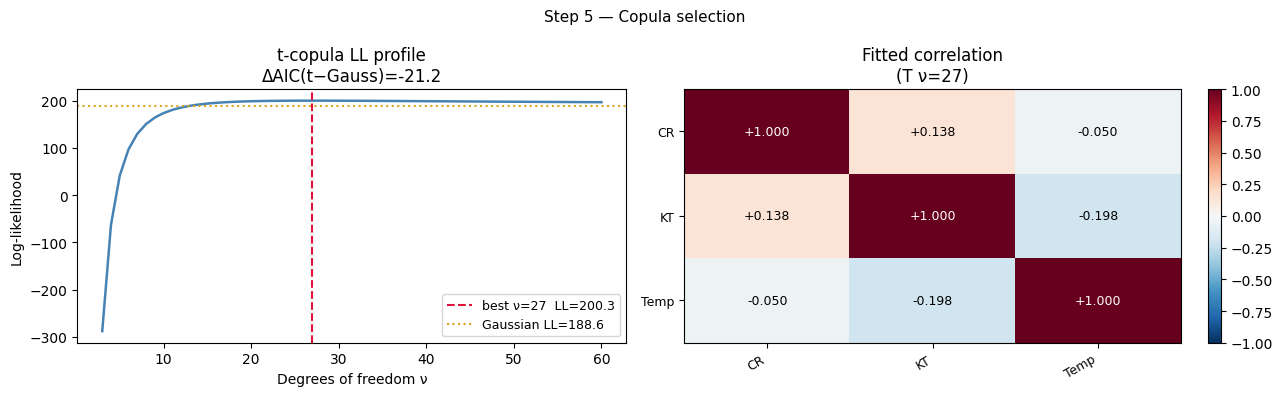

In [113]:
# STEP 5F — Plots
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
 
# LL profile
ax = axes[0]
ax.plot(nu_grid_cop, ll_t_grid, lw=1.8, color="steelblue")
ax.axvline(best_nu, color="crimson", lw=1.5, ls="--",
           label=f"best ν={best_nu}  LL={best_ll_t:.1f}")
ax.axhline(ll_gauss, color="goldenrod", lw=1.5, ls=":",
           label=f"Gaussian LL={ll_gauss:.1f}")
ax.set_xlabel("Degrees of freedom ν")
ax.set_ylabel("Log-likelihood")
ax.set_title(f"t-copula LL profile\nΔAIC(t−Gauss)={delta_aic:.1f}")
ax.legend(fontsize=9)
 
# correlation heatmap
ax = axes[1]
im = ax.imshow(corr_copula, vmin=-1, vmax=1,
               cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(n_dim))
ax.set_yticks(range(n_dim))
ax.set_xticklabels(short_labels, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)
for i in range(n_dim):
    for j in range(n_dim):
        ax.text(j, i, f"{corr_copula[i,j]:+.3f}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(corr_copula[i,j]) > 0.4 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title(f"Fitted correlation\n({best_copula.upper()}"
             f"{f' ν={nu_copula}' if nu_copula else ''})")
 
plt.suptitle("Step 5 — Copula selection", fontsize=11)
plt.tight_layout()
plt.show()

In [114]:
# STEP 5G — Save
# ─────────────────────────────────────────────────────────────────────────────
 
copula_params = {
    "copula_type":  best_copula,
    "nu":           nu_copula,
    "corr_matrix":  corr_copula.tolist(),
    "chol_matrix":  chol_copula.tolist(),
    "dim":          n_dim,
    "variables":    uniform_cols,
    "labels":       short_labels,
    "ll":           float(best_ll_t if best_copula=="t" else ll_gauss),
    "aic":          float(aic_t     if best_copula=="t" else aic_gauss),
    "bic":          float(bic_t     if best_copula=="t" else bic_gauss),
    "ll_gaussian":  float(ll_gauss),
    "aic_gaussian": float(aic_gauss),
    "delta_aic":    float(delta_aic),
    "n_obs":        int(n_obs),
    "model_comparison": {
        "Gaussian":          {"ll": float(ll_gauss),  "aic": float(aic_gauss), "k": k_gauss},
        f"t(ν={best_nu})":   {"ll": float(best_ll_t), "aic": float(aic_t),     "k": k_t},
    },
    "simulation_note": (
        f"Correlated draws: z_corr = L @ z_indep\n"
        f"z_indep ~ t({nu_copula}) if t-copula, N(0,1) if Gaussian\n"
        f"Variable order: {uniform_cols}"
    ),
}
 
with open(copula_path / "copula_params.pkl", "wb") as f:
    pickle.dump(copula_params, f)
np.save(copula_path / "corr_matrix.npy", corr_copula)
np.save(copula_path / "chol_matrix.npy", chol_copula)
 
print(f"\n── Step 5 complete ──────────────────────────────────────────────")
print(f"  Selected: {best_copula.upper()}"
      f"{f' ν={nu_copula}' if nu_copula else ''}")
print(f"  AIC improvement vs Gaussian: {-delta_aic:.2f}")
print(f"\n  Saved to {copula_path}:")
print(f"    copula_params.pkl  corr_matrix.npy  chol_matrix.npy")


── Step 5 complete ──────────────────────────────────────────────
  Selected: T ν=27
  AIC improvement vs Gaussian: 21.21

  Saved to ..\..\Code\Models\Copula:
    copula_params.pkl  corr_matrix.npy  chol_matrix.npy


# TRAIN-TEST VALIDATION

In [115]:
# Goal: Validate whether the PIT transformation calibrated on 2005–2021
# (training) produces uniform pseudo-observations on 2023–2025 (test).
# Tests whether the copula estimated on the training window is exploitable
# for projection into the following years.

In [116]:
# ── variables and colours ─────────────────────────────────────────────────────
resid_cols_3  = ["eps_cr", "eps_kt", "eps_temp"]
short_labels_3 = ["CR", "KT", "Temp"]
colors_3       = ["darkgreen", "goldenrod", "crimson"]
 
TRAIN_END  = "2021-12-31"
TEST_START = "2023-07-01"

In [117]:
# Split into train and test
# ─────────────────────────────────────────────────────────────────────────────
 
# use df_resid (full aligned sample including crisis flag)
df_train = df_resid[
    (df_resid["date"] <= TRAIN_END) &
    (df_resid["crisis"] == 0)
].copy().reset_index(drop=True)
 
df_test = df_resid[
    (df_resid["date"] >= TEST_START) &
    (df_resid["crisis"] == 0)
].copy().reset_index(drop=True)
 
print("── Train-Test PIT Validation ────────────────────────────────────")
print(f"  Training window : 2005-01-01 → {TRAIN_END}  n={len(df_train)}")
print(f"  Test window     : {TEST_START} → 2025-12-31  n={len(df_test)}")
print(f"  Variables       : {resid_cols_3}")
print(f"\n  Training residual statistics:")
print(f"  {'Series':<12}  {'mean':>8}  {'std':>8}  {'skew':>7}  {'kurt':>7}")
print(f"  {'-'*12}  {'-'*8}  {'-'*8}  {'-'*7}  {'-'*7}")
for col, label in zip(resid_cols_3, short_labels_3):
    s = df_train[col].dropna()
    print(f"  {label:<12}  {s.mean():>8.5f}  {s.std():>8.5f}  "
          f"{stats.skew(s):>7.3f}  {stats.kurtosis(s):>7.3f}")
 
print(f"\n  Test residual statistics:")
print(f"  {'Series':<12}  {'mean':>8}  {'std':>8}  {'skew':>7}  {'kurt':>7}")
print(f"  {'-'*12}  {'-'*8}  {'-'*8}  {'-'*7}  {'-'*7}")
for col, label in zip(resid_cols_3, short_labels_3):
    s = df_test[col].dropna()
    print(f"  {label:<12}  {s.mean():>8.5f}  {s.std():>8.5f}  "
          f"{stats.skew(s):>7.3f}  {stats.kurtosis(s):>7.3f}")

── Train-Test PIT Validation ────────────────────────────────────
  Training window : 2005-01-01 → 2021-12-31  n=5468
  Test window     : 2023-07-01 → 2025-12-31  n=838
  Variables       : ['eps_cr', 'eps_kt', 'eps_temp']

  Training residual statistics:
  Series            mean       std     skew     kurt
  ------------  --------  --------  -------  -------
  CR            -0.00024   0.07175   -0.377    4.429
  KT             0.00278   2.33354   -0.417   -0.351
  Temp          -0.05087   1.00167   -0.644    1.417

  Test residual statistics:
  Series            mean       std     skew     kurt
  ------------  --------  --------  -------  -------
  CR             0.00530   0.08090   -0.510    4.776
  KT            -0.02559   2.36230   -0.404   -0.412
  Temp          -0.03065   1.01301   -0.684    1.877


In [118]:
#Re-estimate PIT parameters on training window only

# CR: t(ν) — re-estimate ν on training window
def t_ll_marginal(nu, x):
    if nu <= 2: return -np.inf
    std_r = x.std(ddof=1)
    scale = std_r * np.sqrt((nu - 2) / nu)
    return float(np.sum(t_dist.logpdf(x, df=nu, loc=0, scale=scale)))
 
nu_grid_tt  = np.arange(2.5, 61.0, 0.5)
cr_train    = df_train["eps_cr"].dropna().values
ll_cr_train = [t_ll_marginal(nu, cr_train) for nu in nu_grid_tt]
nu_cr_train = float(nu_grid_tt[np.argmax(ll_cr_train)])
sigma_cr_train   = float(cr_train.std(ddof=1))
scale_t_cr_train = sigma_cr_train * np.sqrt((nu_cr_train - 2) / nu_cr_train)
 
# KT: Gaussian
sigma_kt_train = float(df_train["eps_kt"].dropna().std(ddof=1))
 
# Temp: t(ν) — re-estimate ν on training window
nu_grid_tt  = np.arange(2.5, 61.0, 0.5)
temp_train    = df_train["eps_temp"].dropna().values
ll_temp_train = [t_ll_marginal(nu, temp_train) for nu in nu_grid_tt]
nu_temp_train = float(nu_grid_tt[np.argmax(ll_temp_train)])
sigma_temp_train   = float(temp_train.std(ddof=1))
scale_t_temp_train = sigma_temp_train * np.sqrt((nu_temp_train - 2) / nu_temp_train)
 
print(f"\n── Step TT2: Training-window PIT parameters ─────────────────────")
print(f"  CR   : t(ν={nu_cr_train:.1f})  σ={sigma_cr_train:.5f}  "
      f"scale_t={scale_t_cr_train:.5f}")
print(f"  KT   : Gaussian  σ={sigma_kt_train:.5f}")
print(f"  Temp : t(ν={nu_temp_train:.1f})  σ={sigma_temp_train:.5f}  "
      f"scale_t={scale_t_temp_train:.5f}")
print(f"\n  Full-sample parameters (for comparison):")
print(f"  CR   : t(ν={nu_cr})  scale_t={scale_t_cr:.5f}")
print(f"  KT   : σ={sigma_kt:.5f}")
print(f"  Temp : t(ν={nu_temp})  scale_t={scale_temp:.5f}")


── Step TT2: Training-window PIT parameters ─────────────────────
  CR   : t(ν=4.0)  σ=0.07175  scale_t=0.05073
  KT   : Gaussian  σ=2.33354
  Temp : t(ν=7.5)  σ=1.00167  scale_t=0.85778

  Full-sample parameters (for comparison):
  CR   : t(ν=4.072727272727272)  scale_t=0.05211
  KT   : σ=2.33721
  Temp : t(ν=7.454545454545455)  scale_t=0.85807


In [119]:
#Apply training PIT to both windows
# ─────────────────────────────────────────────────────────────────────────────
 
def apply_pit_3var(df, nu_cr_p, scale_t_cr_p, sigma_kt_p, sigma_temp_p):
    """Apply PIT using given parameters to a residual dataframe."""
    U_cr_   = t_dist.cdf(df["eps_cr"].values   / scale_t_cr_p, df=nu_cr_p)
    U_kt_   = norm.cdf(df["eps_kt"].values,   0, sigma_kt_p)
    U_temp_ = norm.cdf(df["eps_temp"].values, 0, sigma_temp_p)
    return U_cr_, U_kt_, U_temp_
 
# training uniforms
U_cr_tr, U_kt_tr, U_temp_tr = apply_pit_3var(
    df_train, nu_cr_train, scale_t_cr_train,
    sigma_kt_train, sigma_temp_train
)
 
# test uniforms — using TRAINING parameters (the key test)
U_cr_te, U_kt_te, U_temp_te = apply_pit_3var(
    df_test, nu_cr_train, scale_t_cr_train,
    sigma_kt_train, sigma_temp_train
)
 
U_train = np.column_stack([U_cr_tr, U_kt_tr, U_temp_tr])
U_test  = np.column_stack([U_cr_te, U_kt_te, U_temp_te])
 
# clip
eps_c   = 1e-6
U_train = np.clip(U_train, eps_c, 1-eps_c)
U_test  = np.clip(U_test,  eps_c, 1-eps_c)

In [120]:

from scipy.stats import kstest, ks_2samp

# Uniformity tests on each margin
print(f"\n── Step TT4: Uniformity tests ───────────────────────────────────")
print(f"  Reference U[0,1]: mean=0.500  std=0.289")
print(f"\n  {'Series':<8}  {'Window':<10}  {'mean':>7}  {'std':>7}  "
      f"{'KS stat':>8}  {'KS p':>8}  {'AD stat':>8}  result")
print(f"  {'-'*8}  {'-'*10}  {'-'*7}  {'-'*7}  "
      f"{'-'*8}  {'-'*8}  {'-'*8}  ------")

tt_results = {}

for j, label in enumerate(short_labels_3):
    # Iterate through training and test sets
    for window, U_w in [
        ("training", U_train[:, j]),
        ("test",     U_test[:, j]),
    ]:
        # 1. Kolmogorov-Smirnov Test for Uniformity
        ks_stat, ks_p = stats.kstest(U_w, "uniform")
        
        # 2. Note: Anderson-Darling is omitted for "uniform" as Scipy doesn't support it.
        # We use 'N/A' for the print and 0.0 for the results dictionary.
        ad_stat_val = 0.0
        
        # Determine result based on KS p-value (alpha = 0.05)
        result = "✓ uniform" if ks_p >= 0.05 else "✗ non-uniform"
        
        # Print formatted row
        print(f"  {label:<8}  {window:<10}  {U_w.mean():>7.4f}  "
              f"{U_w.std():>7.4f}  {ks_stat:>8.4f}  {ks_p:>8.4f}  "
              f"{'N/A':>8}  {result}")
        
        # Store results
        tt_results[f"{label}_{window}"] = {
            "mean": U_w.mean(), 
            "std": U_w.std(),
            "ks_stat": ks_stat, 
            "ks_p": ks_p,
            "ad_stat": ad_stat_val,
        }

# KS test: train vs test distributions (are they from the same distribution?)
print(f"\n  KS 2-sample test: training vs test uniform (same distribution?)")
print(f"  {'Series':<8}  {'KS stat':>8}  {'p-value':>9}  result")
print(f"  {'-'*8}  {'-'*8}  {'-'*9}  ------")

for j, label in enumerate(short_labels_3):
    ks_s, ks_p = ks_2samp(U_train[:, j], U_test[:, j])
    result = "✓ same distribution" if ks_p > 0.05 else "✗ distributions differ"
    print(f"  {label:<8}  {ks_s:>8.4f}  {ks_p:>9.4f}  {result}")


── Step TT4: Uniformity tests ───────────────────────────────────
  Reference U[0,1]: mean=0.500  std=0.289

  Series    Window         mean      std   KS stat      KS p   AD stat  result
  --------  ----------  -------  -------  --------  --------  --------  ------
  CR        training     0.4992   0.2891    0.0181    0.0559       N/A  ✓ uniform
  CR        test         0.5243   0.3030    0.0558    0.0105       N/A  ✗ non-uniform
  KT        training     0.5142   0.2936    0.0650    0.0000       N/A  ✗ non-uniform
  KT        test         0.5112   0.2965    0.0715    0.0004       N/A  ✗ non-uniform
  Temp      training     0.4981   0.2778    0.0361    0.0000       N/A  ✗ non-uniform
  Temp      test         0.5040   0.2775    0.0497    0.0308       N/A  ✗ non-uniform

  KS 2-sample test: training vs test uniform (same distribution?)
  Series     KS stat    p-value  result
  --------  --------  ---------  ------
  CR          0.0585     0.0133  ✗ distributions differ
  KT          0.0

In [121]:
from scipy.stats import t as t_dist
import numpy as np

# 1. Define a robust re-usable estimation function
def estimate_t_params(data, label):
    """Finds best nu (degrees of freedom) and scale for a series."""
    x = data.dropna().values
    nu_grid = np.arange(2.1, 61.0, 0.5) # nu must be > 2 for variance to exist
    
    def get_ll(nu):
        # We use the relationship: scale = std * sqrt((nu-2)/nu)
        std_r = x.std(ddof=1)
        scale = std_r * np.sqrt((nu - 2) / nu)
        return np.sum(t_dist.logpdf(x, df=nu, loc=0, scale=scale))
    
    log_likelihoods = [get_ll(nu) for nu in nu_grid]
    best_nu = float(nu_grid[np.argmax(log_likelihoods)])
    
    sigma = float(x.std(ddof=1))
    scale = sigma * np.sqrt((best_nu - 2) / best_nu)
    
    return best_nu, sigma, scale

# 2. Re-estimate parameters for ALL three using Student-t
print(f"\n── Step TT2: Training-window PIT parameters (Improved) ──────────")

# CR Parameters
nu_cr_train, sigma_cr_train, scale_t_cr_train = estimate_t_params(df_train["eps_cr"], "CR")

# KT Parameters (Upgraded from Gaussian to Student-t)
nu_kt_train, sigma_kt_train, scale_t_kt_train = estimate_t_params(df_train["eps_kt"], "KT")

# Temp Parameters (Upgraded from Gaussian to Student-t)
nu_temp_train, sigma_temp_train, scale_t_temp_train = estimate_t_params(df_train["eps_temp"], "Temp")

print(f"  CR   : t(ν={nu_cr_train:.1f})   scale={scale_t_cr_train:.5f}")
print(f"  KT   : t(ν={nu_kt_train:.1f})   scale={scale_t_kt_train:.5f}")
print(f"  Temp : t(ν={nu_temp_train:.1f})   scale={scale_t_temp_train:.5f}")


── Step TT2: Training-window PIT parameters (Improved) ──────────
  CR   : t(ν=4.1)   scale=0.05135
  KT   : t(ν=60.6)   scale=2.29471
  Temp : t(ν=7.6)   scale=0.85983


In [122]:
from scipy.stats import t as t_dist
import numpy as np

# Parameter Estimation & Stability Check


def estimate_t_params(data):
    """Finds best nu (degrees of freedom) and scale for a series."""
    x = data.dropna().values
    if len(x) == 0: return np.nan, np.nan, np.nan
    
    nu_grid = np.arange(2.1, 61.0, 0.5) 
    
    def get_ll(nu):
        std_r = x.std(ddof=1)
        scale = std_r * np.sqrt((nu - 2) / nu)
        return np.sum(t_dist.logpdf(x, df=nu, loc=0, scale=scale))
    
    log_likelihoods = [get_ll(nu) for nu in nu_grid]
    best_nu = float(nu_grid[np.argmax(log_likelihoods)])
    
    sigma = float(x.std(ddof=1))
    scale = sigma * np.sqrt((best_nu - 2) / best_nu)
    
    return best_nu, sigma, scale

# Dictionary to store results for comparison
comparison_results = {}

print(f"\nParameter Estimation & Stability Check ─────────────")
print(f"{'Series':<8} | {'Train nu':>10} | {'Test nu':>10} | {'Stability':>12}")
print("-" * 50)

for label, col in [("CR", "eps_cr"), ("KT", "eps_kt"), ("Temp", "eps_temp")]:
    # 1. Estimate on Training (These are the variables you use for the actual model)
    nu_tr, sig_tr, sc_tr = estimate_t_params(df_train[col])
    
    # 2. Estimate on Test (For diagnostic purposes only!)
    nu_te, sig_te, sc_te = estimate_t_params(df_test[col])
    
    # Calculate stability (percentage difference in nu)
    stability = abs(nu_tr - nu_te)
    status = "Stable" if stability <= 5 else "Shifted"
    
    print(f"{label:<8} | {nu_tr:>10.1f} | {nu_te:>10.1f} | {status:>12}")
    
    # Store training params for use in Step TT3/TT4
    if label == "CR":
        nu_cr_train, scale_t_cr_train = nu_tr, sc_tr
    elif label == "KT":
        nu_kt_train, scale_t_kt_train = nu_tr, sc_tr
    elif label == "Temp":
        nu_temp_train, scale_t_temp_train = nu_tr, sc_tr


Parameter Estimation & Stability Check ─────────────
Series   |   Train nu |    Test nu |    Stability
--------------------------------------------------
CR       |        4.1 |        4.1 |       Stable
KT       |       60.6 |       60.6 |       Stable
Temp     |        7.6 |        6.6 |       Stable
